# Diagnóstico temporal del dengue y diseño de la evaluación

## Objetivo

Antes de construir clústeres y modelos de pronóstico, comprobaremos:

- La correspondencia de fechas y estados entre casos, incidencia y clima.
- Las limitaciones de los cortes anuales de dengue.
- Qué semanas cumplen distintos criterios de exclusión.
- La frecuencia de ceros, la variabilidad y las asociaciones temporales.
- Qué antecedentes podemos utilizar para pronosticar.

Conservaremos el calendario completo. Una semana excluida no se convertirá
en cero ni se eliminará para acercar artificialmente otras semanas.

## 1. Carga y comprobación de las matrices epidemiológicas

Utilizaremos dos matrices:

- **Casos:** número de casos confirmados registrados por semana y estado.
- **Incidencia:** casos semanales por 100,000 habitantes.

Las columnas representan estados y las filas representan semanas de
lunes a domingo, etiquetadas con el domingo.

Esta primera celda comprobará que las matrices tienen fechas únicas,
semanas consecutivas, valores numéricos finitos y no negativos, y los
mismos estados en el mismo orden.

Estas comprobaciones validan la estructura de las matrices.
No demuestran que los casos estén consolidados ni que un cero represente
ausencia de enfermedad.

Los archivos originales permanecerán sin cambios. Las figuras de esta
versión se guardarán en una carpeta nueva.

In [1]:
from pathlib import Path
from io import BytesIO
import json
import re
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.colors import ListedColormap, BoundaryNorm, PowerNorm
from matplotlib.patches import Patch
from IPython.display import display

In [14]:
PROYECTO_DIR = Path("/Users/juanalbertomartinez/Desktop/Dengue")
BASE = PROYECTO_DIR / "datos_dengue_historicos"
SERIES_DIR = BASE / "series_temporales"
FIG_DIR = BASE / "figuras_05_diagnostico_temporal"
RESULTADOS_DIR = BASE / "resultados_05_diagnostico_temporal"

FIG_DIR.mkdir(parents=True, exist_ok=True)

def cargar_matriz(ruta):
    """Leer una matriz y comprobar su calendario y valores."""
    datos = pd.read_csv(ruta, encoding="utf-8-sig")
    assert "FECHA" in datos.columns, f"Falta FECHA en {ruta.name}"

    fechas = pd.DatetimeIndex(
        pd.to_datetime(datos.pop("FECHA"), errors="raise"),
        name="FECHA",
    )
    matriz = datos.apply(pd.to_numeric, errors="raise")
    matriz.index = fechas

    assert len(matriz) > 1, f"Matriz insuficiente: {ruta.name}"
    assert fechas.notna().all(), f"Fechas ausentes: {ruta.name}"
    assert fechas.is_unique, f"Fechas duplicadas: {ruta.name}"
    assert fechas.is_monotonic_increasing, f"Fechas desordenadas: {ruta.name}"
    assert fechas.equals(fechas.normalize()), f"Fechas con hora: {ruta.name}"
    assert (fechas.dayofweek == 6).all(), f"Etiquetas no dominicales: {ruta.name}"
    assert fechas.to_series().diff().dropna().eq(
        pd.Timedelta(days=7)
    ).all(), f"Calendario con huecos: {ruta.name}"
    assert matriz.columns.is_unique, f"Columnas duplicadas: {ruta.name}"
    assert np.isfinite(matriz.to_numpy(dtype=float)).all(), (
        f"Valores nulos o infinitos: {ruta.name}"
    )

    return matriz

casos = cargar_matriz(
    SERIES_DIR / "casos_semanales_dengue_por_estado_2020_2026.csv"
)
incidencia = cargar_matriz(
    SERIES_DIR / "incidencia_semanal_dengue_por_estado_2020_2026.csv"
)

assert casos.index.equals(incidencia.index), "Las fechas no coinciden."
assert casos.columns.equals(incidencia.columns), "Los estados no coinciden."
assert casos.shape[1] == 32, "Se esperaban 32 estados."
assert (casos.to_numpy() >= 0).all(), "Hay casos negativos."
assert (incidencia.to_numpy() >= 0).all(), "Hay incidencias negativas."
assert np.equal(casos.to_numpy(), np.floor(casos.to_numpy())).all(), (
    "Hay conteos de casos no enteros."
)

estados = casos.columns.tolist()

resumen_matrices = pd.DataFrame([
    {
        "MATRIZ": nombre,
        "SEMANAS": len(matriz),
        "ESTADOS": matriz.shape[1],
        "PRIMERA_FECHA": matriz.index.min(),
        "ULTIMA_FECHA": matriz.index.max(),
    }
    for nombre, matriz in [("CASOS", casos), ("INCIDENCIA", incidencia)]
])

display(resumen_matrices)
print("Fechas y estados alineados; calendario y valores comprobados.")
print(f"Total de casos: {casos.to_numpy().sum():,.0f}")

,MATRIZ,SEMANAS,ESTADOS,PRIMERA_FECHA,ULTIMA_FECHA
0,CASOS,334,32,2020-01-05,2026-05-24
1,INCIDENCIA,334,32,2020-01-05,2026-05-24


Fechas y estados alineados; calendario y valores comprobados.
Total de casos: 242,999


## 1.1. Extremos del periodo observado

Las semanas representan intervalos de lunes a domingo. Sin embargo,
los registros individuales pueden comenzar o terminar dentro de una semana.

Leeremos las fechas de inicio de síntomas para identificar esas semanas
en los extremos de la serie.

Por ejemplo, una semana etiquetada con el domingo 5 de enero comienza
el lunes 30 de diciembre del año anterior.

### ¿Qué significa una semana marcada?

Significa que parte de sus días queda fuera del rango de síntomas observado.

Este rango no demuestra cobertura administrativa: la última fecha de
síntomas registrada no necesariamente coincide con el cierre de la base.

La figura mostrará la serie nacional y un detalle de las últimas doce
semanas. Los extremos marcados requieren revisión antes de interpretar
sus conteos como comparables con los de una semana completa.

In [15]:
# Rango de síntomas de los registros individuales.
fechas_sintomas = pd.to_datetime(
    pd.read_csv(
        BASE / "csv_unificado" / "dengue_2020_2026.csv",
        usecols=["FECHA"],
    )["FECHA"],
    errors="raise",
).dt.normalize()

assert fechas_sintomas.notna().all()
primera_sintoma, ultima_sintoma = (
    fechas_sintomas.min(), fechas_sintomas.max()
)

calendario = pd.DataFrame(index=casos.index)
calendario["INICIO_SEMANA"] = calendario.index - pd.Timedelta(days=6)
calendario["FIN_SEMANA"] = calendario.index
calendario["CASOS_NACIONALES"] = casos.sum(axis=1)

# Intersección de cada semana con el rango observado, contando ambos extremos.
inicio_interseccion = calendario["INICIO_SEMANA"].clip(lower=primera_sintoma)
fin_interseccion = calendario["FIN_SEMANA"].clip(upper=ultima_sintoma)

calendario["DIAS_DENTRO_RANGO"] = (
    (fin_interseccion - inicio_interseccion).dt.days + 1
).clip(lower=0, upper=7)

calendario["REVISAR_EXTREMO"] = calendario["DIAS_DENTRO_RANGO"].lt(7)

print(f"Rango de síntomas observado: {primera_sintoma:%Y-%m-%d} a {ultima_sintoma:%Y-%m-%d}")
print("\nSemanas que exceden ese rango:")
display(calendario.loc[calendario["REVISAR_EXTREMO"]])

Rango de síntomas observado: 2020-01-01 a 2026-05-20

Semanas que exceden ese rango:


,INICIO_SEMANA,FIN_SEMANA,CASOS_NACIONALES,DIAS_DENTRO_RANGO,REVISAR_EXTREMO
FECHA,,,,,
2020-01-05,2019-12-30,2020-01-05,175,5,True
2026-05-24,2026-05-18,2026-05-24,9,3,True


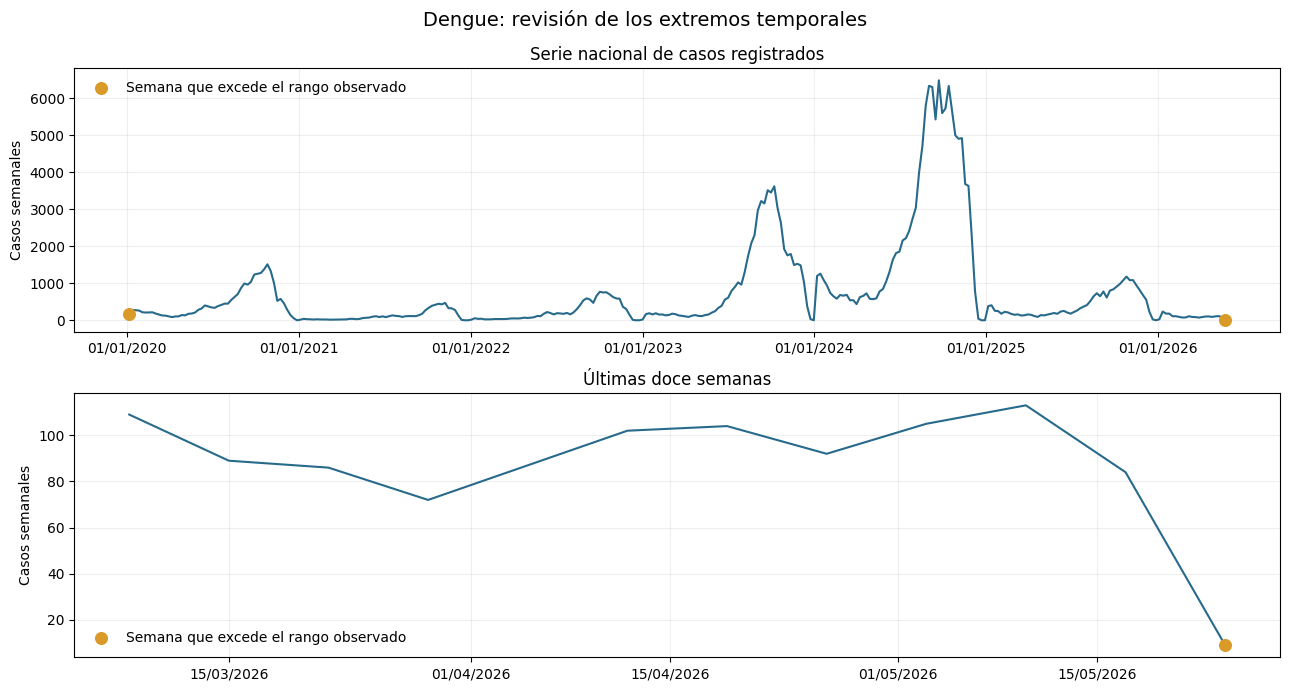

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

for ax, datos, titulo in zip(
    axes,
    [calendario, calendario.tail(12)],
    ["Serie nacional de casos registrados", "Últimas doce semanas"],
):
    ax.plot(
        datos.index, datos["CASOS_NACIONALES"],
        color="#276A8B")
    
    extremos = datos.loc[datos["REVISAR_EXTREMO"]]
    ax.scatter(
        extremos.index, extremos["CASOS_NACIONALES"],
        color="#D99A28", s=70, zorder=3,
        label="Semana que excede el rango observado",
    )
    ax.set(title=titulo, ylabel="Casos semanales")
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
    ax.legend(frameon=False)

axes[1].tick_params()
fig.suptitle("Dengue: revisión de los extremos temporales", fontsize=14)
fig.tight_layout()

fig.savefig(
    FIG_DIR / "fig_01_serie_nacional_revision_extremos.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

## 2. Auditoría de los cortes anuales

La base analítica utiliza el último ZIP válido seleccionado de cada año.
Eso no garantiza que contenga todos los casos del año consolidados.

Debemos distinguir tres fechas:

- **Fecha del ZIP:** fecha registrada en el manifiesto.
- **Actualización interna:** fecha indicada dentro del archivo.
- **Inicio de síntomas:** fecha correspondiente a cada registro.

La actualización interna puede ser anterior a la fecha del ZIP.
Además, un caso cercano a la actualización puede no haber sido
registrado o confirmado todavía.

### ¿Qué comprobaremos?

Para los cortes de 2020–2025 revisaremos:

1. Fechas de actualización y síntomas.
2. Valores ausentes o no interpretables.
3. Síntomas posteriores a la actualización o a la fecha del ZIP.
4. Registros cuyo año de síntomas sea distinto del año seleccionado.
5. Conteo y última fecha de síntomas de los confirmados consistentes.

Usaremos `ESTATUS_CASO == 2`, el mismo filtro de confirmados del notebook 00.

Los conteos corresponden a los archivos originales, antes de la limpieza
geográfica. Por eso pueden diferir ligeramente de los de la base analítica.

Esta auditoría identificará problemas temporales. Cumplir sus controles
no demuestra que un registro sea correcto ni que el corte esté consolidado.

In [17]:
import csv

ANIOS = list(range(2020, 2026))

# Seleccionar los últimos cortes válidos registrados en el manifiesto.
manifest = pd.read_csv(BASE / "manifest_descargas_dengue.csv")
manifest["year"] = pd.to_numeric(manifest["year"], errors="raise")
manifest["publication_date"] = pd.to_datetime(
    manifest["publication_date"], errors="coerce"
)
manifest["ZIP_VALIDO"] = (
    manifest["zip_ok"].astype(str).str.strip().str.lower()
    .isin(["true", "1", "1.0", "yes", "si", "sí"])
)

cortes = (
    manifest.loc[
        manifest["ZIP_VALIDO"]
        & manifest["year"].isin(ANIOS)
        & manifest["publication_date"].notna()
    ]
    .sort_values(["year", "publication_date", "zip_filename"])
    .groupby("year").tail(1)
    .set_index("year")
    .reindex(ANIOS)
)

assert cortes["zip_filename"].notna().all(), "Falta algún corte anual."

def leer_fechas_y_estatus(ruta):
    """Detectar el formato y leer solo los campos necesarios del ZIP."""
    with zipfile.ZipFile(ruta) as archivo:
        miembros = [
            nombre for nombre in archivo.namelist()
            if "__MACOSX" not in nombre
            and Path(nombre).suffix.lower() in [".csv", ".txt"]
        ]
        preferidos = [n for n in miembros if "dengue" in n.lower()]
        assert miembros, f"No hay CSV/TXT en {ruta.name}"
        miembro = max(
            preferidos or miembros,
            key=lambda n: archivo.getinfo(n).file_size,
        )
        contenido = archivo.read(miembro)

    for encoding in ["utf-8-sig", "cp1252", "latin1"]:
        try:
            cabecera = contenido[:8192].decode(encoding)
            break
        except UnicodeError:
            continue

    separador = csv.Sniffer().sniff(
        cabecera, delimiters=",;\t|"
    ).delimiter

    normalizar = lambda nombre: nombre.lstrip("\ufeff").strip().upper()
    necesarias = {
        "FECHA_SIGN_SINTOMAS", "FECHA_ACTUALIZACION", "ESTATUS_CASO"
    }
    datos = pd.read_csv(
        BytesIO(contenido), encoding=encoding, sep=separador,
        dtype=str, usecols=lambda nombre: normalizar(nombre) in necesarias,
    )
    datos.columns = [normalizar(nombre) for nombre in datos.columns]
    assert necesarias <= set(datos.columns), f"Faltan campos en {ruta.name}"

    return pd.DataFrame({
        "SINTOMAS": pd.to_datetime(
            datos["FECHA_SIGN_SINTOMAS"],
            format="mixed", dayfirst=True, errors="coerce",
        ),
        "ACTUALIZACION": pd.to_datetime(
            datos["FECHA_ACTUALIZACION"],
            format="mixed", dayfirst=True, errors="coerce",
        ),
        "ESTATUS": pd.to_numeric(datos["ESTATUS_CASO"], errors="coerce"),
    })

filas_auditoria = []

for anio in ANIOS:
    corte = cortes.loc[anio]
    fecha_zip = corte["publication_date"].normalize()
    ruta = BASE / "zips" / str(anio) / corte["zip_filename"]
    datos = leer_fechas_y_estatus(ruta)

    fechas_validas = datos[["SINTOMAS", "ACTUALIZACION"]].notna().all(axis=1)
    post_actualizacion = fechas_validas & (
        datos["SINTOMAS"] > datos["ACTUALIZACION"]
    )
    post_zip = datos["SINTOMAS"] > fecha_zip
    confirmados = datos["ESTATUS"].eq(2)
    consistentes = fechas_validas & ~post_actualizacion & ~post_zip

    filas_auditoria.append({
        "ANIO": anio,
        "FECHA_ZIP": fecha_zip,
        "ACTUALIZACION_MIN": datos["ACTUALIZACION"].min(),
        "ACTUALIZACION_MAX": datos["ACTUALIZACION"].max(),
        "N_ACTUALIZACIONES": datos["ACTUALIZACION"].nunique(),
        "REGISTROS": len(datos),
        "SINTOMAS_NULOS": int(datos["SINTOMAS"].isna().sum()),
        "ACTUALIZACIONES_NULAS": int(datos["ACTUALIZACION"].isna().sum()),
        "ESTATUS_NULOS": int(datos["ESTATUS"].isna().sum()),
        "SINTOMAS_POST_ACTUALIZACION": int(post_actualizacion.sum()),
        "SINTOMAS_POST_ZIP": int(post_zip.sum()),
        "REGISTROS_OTRO_ANIO": int(
            (datos["SINTOMAS"].notna()
             & datos["SINTOMAS"].dt.year.ne(anio)).sum()
        ),
        "CONFIRMADOS": int(confirmados.sum()),
        "CONFIRMADOS_INCONSISTENTES": int(
            (confirmados & (post_actualizacion | post_zip)).sum()
        ),
        "ULTIMO_SINTOMA_CONFIRMADO_CONSISTENTE": (
            datos.loc[confirmados & consistentes, "SINTOMAS"].max()
        ),
    })

    if anio == 2024:
        datos_corte_2024 = datos.copy()

auditoria = pd.DataFrame(filas_auditoria)

print("Fechas y extremos de confirmados:")
display(auditoria[[
    "ANIO", "FECHA_ZIP", "ACTUALIZACION_MIN", "ACTUALIZACION_MAX",
    "N_ACTUALIZACIONES", "CONFIRMADOS",
    "ULTIMO_SINTOMA_CONFIRMADO_CONSISTENTE",
]])

print("\nControles de calidad temporal:")
display(auditoria.drop(columns=[
    "FECHA_ZIP", "ACTUALIZACION_MIN", "ACTUALIZACION_MAX",
    "N_ACTUALIZACIONES", "CONFIRMADOS",
    "ULTIMO_SINTOMA_CONFIRMADO_CONSISTENTE",
]))

Fechas y extremos de confirmados:


,ANIO,FECHA_ZIP,ACTUALIZACION_MIN,ACTUALIZACION_MAX,N_ACTUALIZACIONES,CONFIRMADOS,ULTIMO_SINTOMA_CONFIRMADO_CONSISTENTE
0,2020,2020-12-31,2020-12-30,2020-12-30,1,24225,2020-12-20
1,2021,2021-12-30,2021-12-13,2021-12-13,1,6327,2021-12-09
2,2022,2022-12-29,2022-12-12,2022-12-12,1,12122,2022-12-06
3,2023,2023-12-27,2023-12-27,2023-12-27,1,53324,2023-12-21
4,2024,2024-12-19,2024-12-16,2024-12-16,1,123141,2024-12-11
5,2025,2025-12-26,2025-12-23,2025-12-23,1,21733,2025-12-17



Controles de calidad temporal:


,ANIO,REGISTROS,SINTOMAS_NULOS,ACTUALIZACIONES_NULAS,ESTATUS_NULOS,SINTOMAS_POST_ACTUALIZACION,SINTOMAS_POST_ZIP,REGISTROS_OTRO_ANIO,CONFIRMADOS_INCONSISTENTES
0,2020,120239,0,0,0,0,0,0,0
1,2021,35413,0,0,0,0,0,0,0
2,2022,57730,0,0,0,0,0,0,0
3,2023,274357,0,0,0,0,0,0,0
4,2024,550247,0,0,0,1,1,0,0
5,2025,143166,0,0,0,1,1,0,0


## 2.1. Registros de fin de año y fechas de corte

Las figuras permiten distinguir dos aspectos de la auditoría:

- **Figura 02:** casos confirmados de la base analítica durante noviembre
  y diciembre de cada año, junto con las fechas del ZIP y de actualización.
- **Figura 03:** registros diarios de diciembre de 2024 por estatus,
  antes de la limpieza geográfica.

La primera utiliza la base analítica; la segunda utiliza el archivo original.
Sus conteos no tienen por qué coincidir exactamente.

En la figura de 2024 señalaremos el registro cuya fecha de síntomas
es posterior a la actualización. Lo mostraremos para documentar
la inconsistencia, sin corregirlo ni eliminarlo del archivo.

Los descensos próximos al corte requieren cautela: estas figuras no
permiten separar una disminución real de casos de los efectos del
registro y la confirmación.

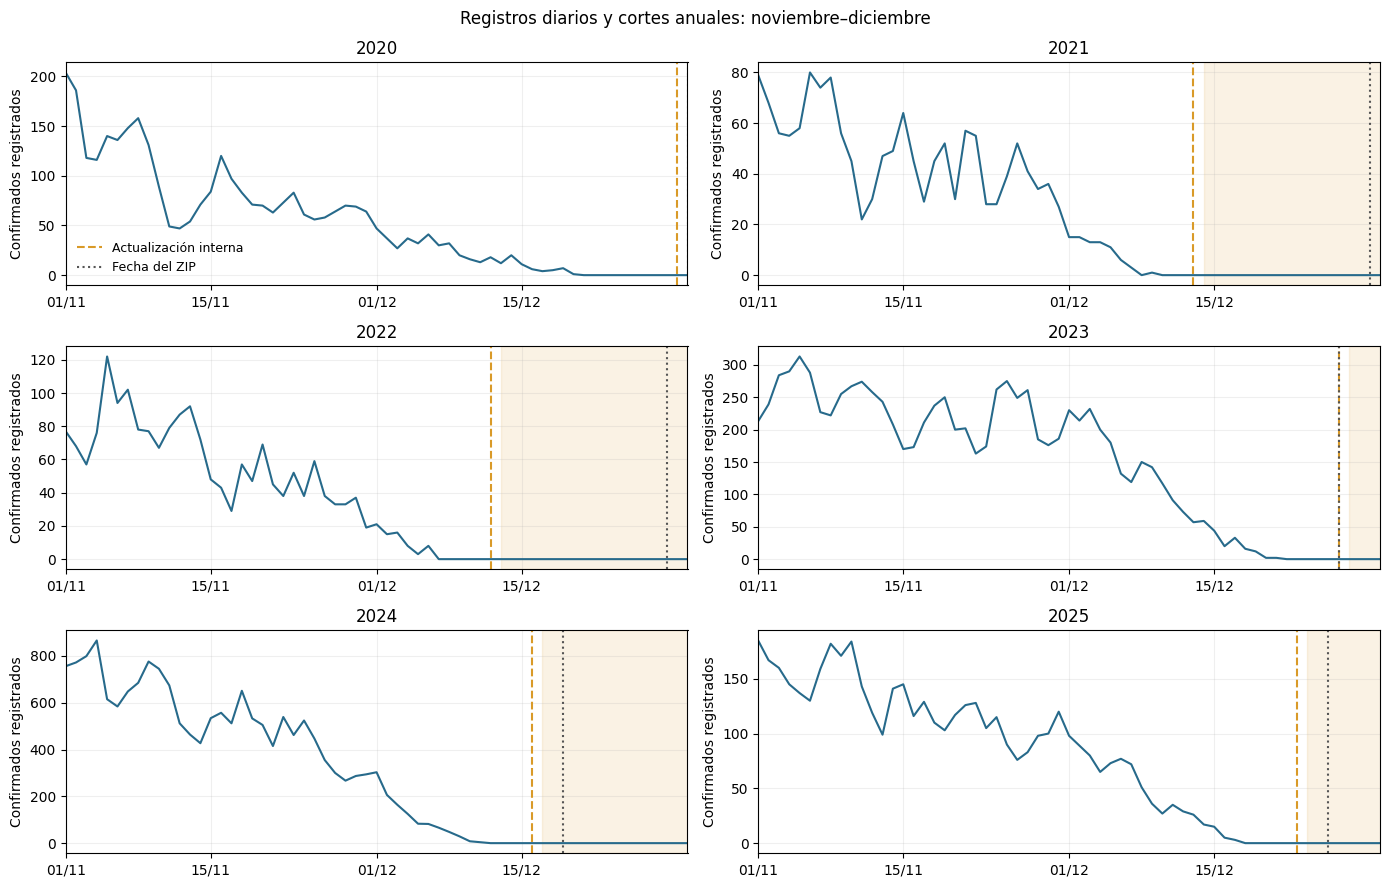

In [18]:
# Conteos diarios de la base analítica: solo confirmados, tras limpieza.
casos_diarios = fechas_sintomas.value_counts().sort_index()
auditoria_por_anio = auditoria.set_index("ANIO")

# noviembre y diciembre de los seis años.
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for ax, anio in zip(axes.flat, ANIOS):
    fechas = pd.date_range(f"{anio}-11-01", f"{anio}-12-31")
    serie = casos_diarios.reindex(fechas, fill_value=0)
    fila = auditoria_por_anio.loc[anio]

    ax.plot(serie.index, serie, color="#276A8B", linewidth=1.5)
    ax.axvline(
        fila["ACTUALIZACION_MAX"], color="#D99A28",
        linestyle="--", label="Actualización interna",
    )
    ax.axvline(
        fila["FECHA_ZIP"], color="#555555",
        linestyle=":", label="Fecha del ZIP",
    )
    ax.axvspan(
        fila["ACTUALIZACION_MAX"] + pd.Timedelta(days=1),
        fechas.max() + pd.Timedelta(days=1),
        color="#D99A28", alpha=0.12,
    )
    ax.set(title=str(anio), ylabel="Confirmados registrados")
    ax.set_xlim(fechas.min(), fechas.max())
    ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 15]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax.grid(alpha=0.2)

axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Registros diarios y cortes anuales: noviembre–diciembre")
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_02_registros_diarios_y_cortes_anuales.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

Cada panel muestra los confirmados registrados en la base analítica durante noviembre y diciembre de un año.

- **Línea azul:** conteos según la fecha de inicio de síntomas.
- **Línea discontinua naranja:** actualización interna del archivo.
- **Línea punteada gris:** fecha del ZIP registrada en el manifiesto.
- **Franja sombreada:** días posteriores a la actualización interna.

La fecha del ZIP puede ser posterior a la actualización de su contenido. Ninguna de estas fechas garantiza que los registros estén consolidados.

Los descensos cercanos al corte requieren cautela: pueden combinar cambios reales en los casos con retrasos de registro o confirmación. Esta figura no permite separar esos efectos ni estimar el retraso.

Por ello, compararemos diferentes márgenes de exclusión antes de utilizar las semanas finales.


### Importancia:

* **Evaluación del rezago de notificación:** Permite visualizar de forma clara cómo desciende de manera abrupta el número de casos confirmados conforme se avanza hacia las últimas semanas de diciembre en cada año.
* **Identificación de artefactos administrativos:** Ayuda a discernir si la disminución en el número de registros se debe a un comportamiento epidemiológico real (baja en los contagios) o a un **retraso operativo** en la captura, diagnóstico y confirmación de los casos por parte de los sistemas de salud antes del cierre del periodo anual.
* **Robustez en el diseño analítico:** Su análisis es fundamental para el diseño de modelos de pronóstico, ya que previene utilizar datos incompletos o subregistrados al final de cada ciclo anual sin un tratamiento de validación adecuado.

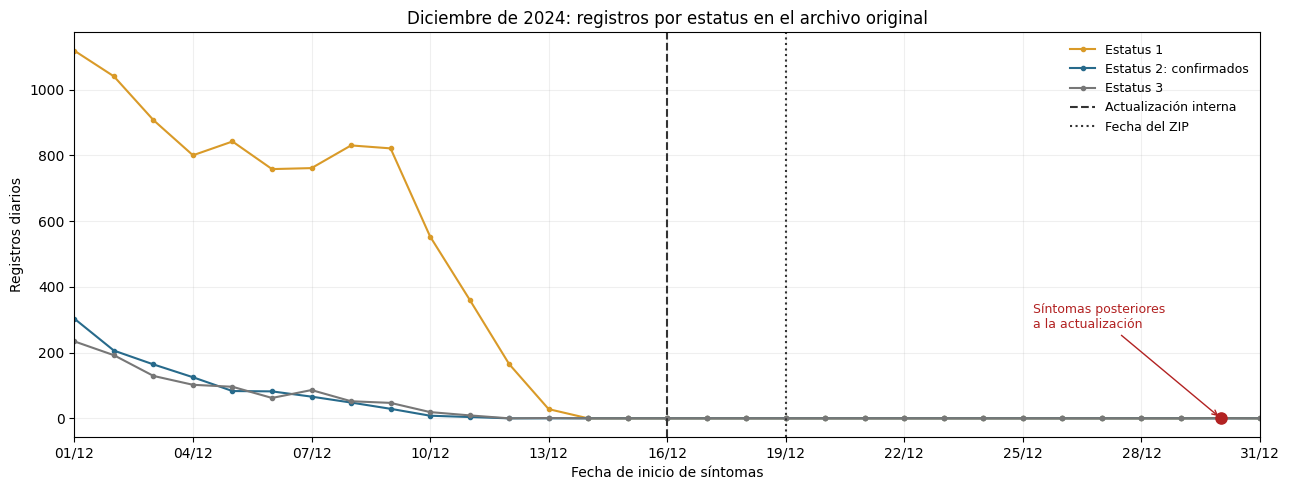

In [19]:
# todos los estatus del archivo original de 2024.
fechas_diciembre = pd.date_range("2024-12-01", "2024-12-31")
diario_estatus_2024 = (
    datos_corte_2024.groupby(["SINTOMAS", "ESTATUS"]).size()
    .unstack(fill_value=0)
    .reindex(index=fechas_diciembre, columns=[1, 2, 3], fill_value=0)
)

corte_2024 = auditoria_por_anio.loc[2024]
inconsistentes_2024 = datos_corte_2024.loc[
    datos_corte_2024["SINTOMAS"] > datos_corte_2024["ACTUALIZACION"]
]

fig, ax = plt.subplots(figsize=(13, 5))
for estatus, color in {1: "#D99A28", 2: "#276A8B", 3: "#777777"}.items():
    etiqueta = "Estatus 2: confirmados" if estatus == 2 else f"Estatus {estatus}"
    ax.plot(
        diario_estatus_2024.index, diario_estatus_2024[estatus],
        color=color, marker="o", markersize=3, label=etiqueta,
    )

ax.axvline(
    corte_2024["ACTUALIZACION_MAX"], color="#333333",
    linestyle="--", label="Actualización interna",
)
ax.axvline(
    corte_2024["FECHA_ZIP"], color="#333333",
    linestyle=":", label="Fecha del ZIP",
)

for registro in inconsistentes_2024.itertuples(index=False):
    fecha, estatus = registro.SINTOMAS, registro.ESTATUS
    if fecha in diario_estatus_2024.index:
        valor = diario_estatus_2024.loc[fecha, estatus]
        ax.scatter(fecha, valor, color="#B22222", s=65, zorder=5)
        ax.annotate(
            "Síntomas posteriores\na la actualización",
            xy=(fecha, valor), xytext=(-135, 65),
            textcoords="offset points",
            arrowprops={"arrowstyle": "->", "color": "#B22222"},
            color="#B22222", fontsize=9,
        )

ax.set(
    title="Diciembre de 2024: registros por estatus en el archivo original",
    ylabel="Registros diarios", xlabel="Fecha de inicio de síntomas",
    xlim=(fechas_diciembre.min(), fechas_diciembre.max()),
)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_03_diciembre_2024_por_estatus.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


* **Auditoría y control de calidad temporal:** Permite identificar visualmente inconsistencias graves en la base de datos oficial, como registros cuya fecha de inicio de síntomas es posterior a la fecha en que se realizó la actualización interna o el empaquetado del archivo.
* **Evidencia del rezago y cierre de captura:** Muestra de forma transparente cómo la captura y notificación de casos caen drásticamente a cero mucho antes de que concluya el mes calendario (coincidiendo con los cortes administrativos), lo que demuestra las limitaciones de utilizar cortes anuales rígidos sin un diagnóstico previo.
* **Transparencia metodológica:** Documenta la presencia de registros anómalos o atípicos sin necesidad de eliminarlos artificialmente, sustentando las decisiones de validación adoptadas en las etapas previas al modelado analítico.

## 3. Escenarios de exclusión temporal

Trabajaremos con las semanas de lunes a domingo completamente contenidas
entre el 1 de enero de 2020 y el 31 de diciembre de 2025.

Para revisar la sensibilidad a los cierres anuales, utilizaremos cuatro
márgenes: 0, 14, 28 y 42 días.

Una semana estará **admitida** si cada uno de sus siete días cumple:

$$
\text{día}
\leq
\text{actualización interna de su año}
-
\text{margen}.
$$

Comprobar cada día es importante para las semanas que cruzan de diciembre
a enero: los días de diciembre deben respetar el corte del año anterior.

### Interpretación

- Un margen mayor excluye más semanas cercanas a las actualizaciones.
- Los márgenes son escenarios hipotéticos; no estimaciones del retraso
  de confirmación.
- Una semana admitida no está necesariamente consolidada.
- Ningún margen se considera definitivo.

Guardaremos una máscara de valores verdaderos y falsos para cada escenario.
No eliminaremos semanas ni convertiremos las excluidas en ceros.

La tabla mostrará las semanas admitidas por año. La figura mostrará
dónde se encuentran las exclusiones.

In [23]:
INICIO_ESTUDIO = pd.Timestamp("2020-01-01")
FIN_ESTUDIO = pd.Timestamp("2025-12-31")
MARGENES = [0, 14, 28, 42]

# Solo semanas completamente contenidas en el periodo de estudio.
dentro_periodo = (
    calendario["INICIO_SEMANA"].ge(INICIO_ESTUDIO)
    & calendario["FIN_SEMANA"].le(FIN_ESTUDIO)
)
calendario_estudio = calendario.loc[dentro_periodo].copy()
casos_estudio = casos.loc[calendario_estudio.index]
incidencia_estudio = incidencia.loc[calendario_estudio.index]

# Exigir una fecha interna común y válida en cada corte anual.
assert auditoria["N_ACTUALIZACIONES"].eq(1).all()
assert auditoria["ACTUALIZACIONES_NULAS"].eq(0).all()

actualizacion_por_anio = auditoria.set_index("ANIO")["ACTUALIZACION_MAX"]

def semana_admitida(domingo, margen):
    dias = pd.date_range(domingo - pd.Timedelta(days=6), domingo)
    limites = [
        actualizacion_por_anio.loc[dia.year] - pd.Timedelta(days=margen)
        for dia in dias
    ]
    return all(dia <= limite for dia, limite in zip(dias, limites))

mascaras = pd.DataFrame({
    f"MARGEN_{margen}": [
        semana_admitida(domingo, margen)
        for domingo in calendario_estudio.index
    ]
    for margen in MARGENES
}, index=calendario_estudio.index)

# Un margen mayor no puede admitir una semana excluida por uno menor.
assert (np.diff(mascaras.to_numpy(dtype=int), axis=1) <= 0).all()

semanas_por_anio = mascaras.groupby(mascaras.index.year).sum()
semanas_por_anio.index.name = "ANIO_ETIQUETA"

resumen_margenes = pd.DataFrame({
    "MARGEN_DIAS": MARGENES,
    "SEMANAS_EN_PERIODO": len(mascaras),
    "SEMANAS_ADMITIDAS": mascaras.sum().to_numpy(),
})
resumen_margenes["SEMANAS_NO_ADMITIDAS"] = (
    resumen_margenes["SEMANAS_EN_PERIODO"]
    - resumen_margenes["SEMANAS_ADMITIDAS"]
)

print("Semanas admitidas por año:")
display(semanas_por_anio)
print("\nResumen de escenarios:")
display(resumen_margenes)



Semanas admitidas por año:


,MARGEN_0,MARGEN_14,MARGEN_28,MARGEN_42
ANIO_ETIQUETA,,,,
2020,51,49,47,45
2021,49,47,45,43
2022,49,47,45,43
2023,51,49,47,45
2024,50,48,46,44
2025,50,48,46,44



Resumen de escenarios:


,MARGEN_DIAS,SEMANAS_EN_PERIODO,SEMANAS_ADMITIDAS,SEMANAS_NO_ADMITIDAS
0,0,312,300,12
1,14,312,288,24
2,28,312,276,36
3,42,312,264,48


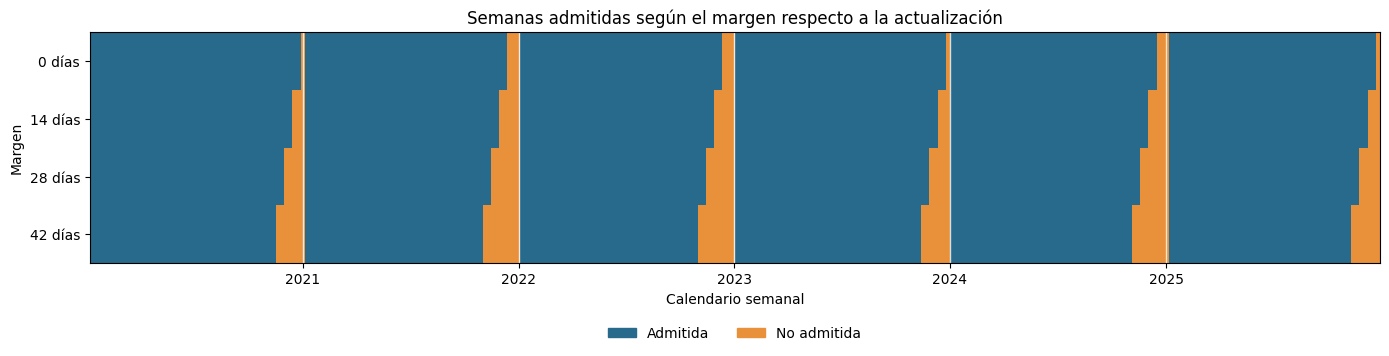

In [24]:
# cada rectángulo representa una semana de lunes a domingo.
bordes_fechas = (mascaras.index - pd.Timedelta(days=6)).append(
    pd.DatetimeIndex([mascaras.index[-1] + pd.Timedelta(days=1)])
)
bordes_x = mdates.date2num(bordes_fechas.to_pydatetime())

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.pcolormesh(
    bordes_x, np.arange(len(MARGENES) + 1),
    mascaras.to_numpy(dtype=int).T,
    cmap=ListedColormap(["#E8913A", "#276A8B"]),
    norm=BoundaryNorm([-0.5, 0.5, 1.5], 2),
    shading="flat",
)
ax.set_yticks(np.arange(len(MARGENES)) + 0.5)
ax.set_yticklabels([f"{margen} días" for margen in MARGENES])
ax.invert_yaxis()

for anio in ANIOS[1:]:
    ax.axvline(
        mdates.date2num(pd.Timestamp(f"{anio}-01-01")),
        color="white", linewidth=1, alpha=0.8,
    )

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set(
    title="Semanas admitidas según el margen respecto a la actualización",
    xlabel="Calendario semanal", ylabel="Margen",
)
ax.legend(
    handles=[
        Patch(color="#276A8B", label="Admitida"),
        Patch(color="#E8913A", label="No admitida"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, -0.22),
    ncol=2, frameon=False,
)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_04_calendario_margenes_actualizacion.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

La figura representa las semanas del periodo de estudio 2020–2025 y su admisión bajo cuatro márgenes: 0, 14, 28 y 42 días.

- **Azul:** semana admitida por la regla del escenario.
- **Naranja:** semana no admitida.
- **Cada fila:** un margen diferente respecto a las actualizaciones internas.

Una semana se admite cuando sus siete días respetan el límite de actualización menos el margen. En semanas que cruzan de año, cada día se compara con la actualización de su propio año.

Al aumentar el margen, se excluyen más semanas cercanas a los cortes. Las máscaras son anidadas: un margen mayor no puede recuperar una semana excluida por uno menor.

Los márgenes son escenarios de sensibilidad. No estiman el retraso real ni garantizan consolidación o disponibilidad en la fecha del pronóstico.

Aunque la primera etiqueta anual visible del eje sea 2021, los rectángulos también incluyen las semanas de 2020.

### Importancia

* **Patrón visual:** Se aprecia que al aumentar el margen de días de exclusión (descendiendo en el eje vertical), se amplía sistemáticamente el bloque de semanas descartadas (franjas naranjas) previas a cada cierre de año o actualización administrativa.

* **Mitigación del subregistro y retraso en la notificación:** Los sistemas de vigilancia epidemiológica presentan un periodo de rezago en el cual los casos tardan semanas en ser confirmados, capturados y consolidados. Esta figura permite dimensionar cómo los datos recientes de cada periodo sufren de inmadurez informativa.
* **Diseño riguroso de la validación:** Es fundamental para establecer una estrategia de validación temporal (o *backtesting*) libre de sesgos. Al definir un margen adecuado (por ejemplo, de 28 o 42 días), se garantiza que los modelos de pronóstico se entrenen y evalúen únicamente con semanas que cuentan con información madura y consolidada, evitando que el modelo aprenda de artefactos causados por el retraso administrativo en la captura.

## 4. Ceros registrados y rachas de ceros

Un cero indica que la base analítica no contiene casos confirmados
para ese estado y semana. No demuestra ausencia de enfermedad.

Compararemos las 312 semanas del periodo completo (`TODAS`) con los
cuatro escenarios de admisión.

Para cada estado calcularemos:

- Porcentaje de semanas consideradas con cero casos.
- Duración de la racha de ceros más larga.

Una racha es una secuencia de semanas consecutivas con cero.
Una semana excluida interrumpe el segmento observado: no se convierte
en cero ni permite unir las semanas anteriores y posteriores.

También registraremos si una racha termina contra el borde del periodo
o una semana excluida. En esos casos, su continuidad más allá del segmento
observado no puede determinarse.

### Figuras

- **Figura 05:** porcentaje de ceros por estado y escenario.
- **Figura 06:** ubicación de ceros, semanas con casos y exclusiones,
  utilizando el margen de 0 días como referencia descriptiva.

Una reducción de la racha máxima al aplicar una máscara puede deberse
a que la máscara corta la secuencia. No significa que mejore el registro.

In [26]:
escenarios = {
    "TODAS": pd.Series(True, index=casos_estudio.index),
    **{nombre: mascaras[nombre] for nombre in mascaras},
}

def encontrar_rachas(serie, mascara):
    """Identificar segmentos consecutivos de ceros admitidos."""
    ceros = (serie.eq(0) & mascara).to_numpy()
    admision = mascara.to_numpy(dtype=bool)
    cambios = np.diff(np.r_[False, ceros, False].astype(int))
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1) - 1

    return [{
        "PRIMERA_ETIQUETA": serie.index[inicio],
        "ULTIMA_ETIQUETA": serie.index[fin],
        "DURACION_SEMANAS": int(fin - inicio + 1),
        "LIMITADA_IZQUIERDA": bool(
            inicio == 0 or not admision[inicio - 1]
        ),
        "LIMITADA_DERECHA": bool(
            fin == len(serie) - 1 or not admision[fin + 1]
        ),
    } for inicio, fin in zip(inicios, finales)]

filas_ceros, filas_rachas = [], []

for escenario, mascara in escenarios.items():
    n_semanas = int(mascara.sum())

    for estado in estados:
        serie = casos_estudio[estado]
        n_ceros = int(serie.loc[mascara].eq(0).sum())
        rachas = encontrar_rachas(serie, mascara)

        filas_ceros.append({
            "ESTADO": estado,
            "ESCENARIO": escenario,
            "SEMANAS": n_semanas,
            "SEMANAS_CERO": n_ceros,
            "PCT_CERO": 100 * n_ceros / n_semanas,
            "RACHA_MAXIMA": max(
                (r["DURACION_SEMANAS"] for r in rachas), default=0
            ),
        })
        filas_rachas.extend(
            {"ESTADO": estado, "ESCENARIO": escenario, **racha}
            for racha in rachas
        )

resumen_ceros = pd.DataFrame(filas_ceros)
detalle_rachas = pd.DataFrame(filas_rachas)

porcentajes_ceros = resumen_ceros.pivot(
    index="ESTADO", columns="ESCENARIO", values="PCT_CERO"
).reindex(columns=list(escenarios))
orden_estados = porcentajes_ceros["TODAS"].sort_values(
    ascending=False
).index
porcentajes_ceros = porcentajes_ceros.loc[orden_estados]

rachas_maximas = resumen_ceros.pivot(
    index="ESTADO", columns="ESCENARIO", values="RACHA_MAXIMA"
).reindex(index=orden_estados, columns=list(escenarios))

print("Porcentaje de semanas con cero:")
display(porcentajes_ceros.round(2))
print("\nRacha máxima observada, en semanas:")
display(rachas_maximas)

Porcentaje de semanas con cero:


ESCENARIO,TODAS,MARGEN_0,MARGEN_14,MARGEN_28,MARGEN_42
ESTADO,,,,,
TLAXCALA,91.99,92.00,91.67,91.67,91.67
ZACATECAS,85.90,85.33,84.72,84.78,85.23
CHIHUAHUA,84.62,84.00,83.68,84.78,85.61
DURANGO,79.49,78.67,78.12,78.99,80.68
AGUASCALIENTES,75.96,75.33,75.00,75.72,76.14
BAJA CALIFORNIA,73.40,72.67,71.88,72.46,74.24
COAHUILA,58.97,57.67,56.94,59.42,62.12
QUERETARO,58.65,57.33,56.25,55.80,56.44
DISTRITO FEDERAL,58.01,56.33,55.56,55.07,56.06



Racha máxima observada, en semanas:


ESCENARIO,TODAS,MARGEN_0,MARGEN_14,MARGEN_28,MARGEN_42
ESTADO,,,,,
TLAXCALA,96,50,48,46,44
ZACATECAS,115,49,47,45,43
CHIHUAHUA,119,50,48,46,44
DURANGO,44,41,41,41,41
AGUASCALIENTES,142,49,47,45,43
BAJA CALIFORNIA,52,39,39,39,39
COAHUILA,35,32,32,32,32
QUERETARO,40,40,40,40,40
DISTRITO FEDERAL,21,21,21,21,21


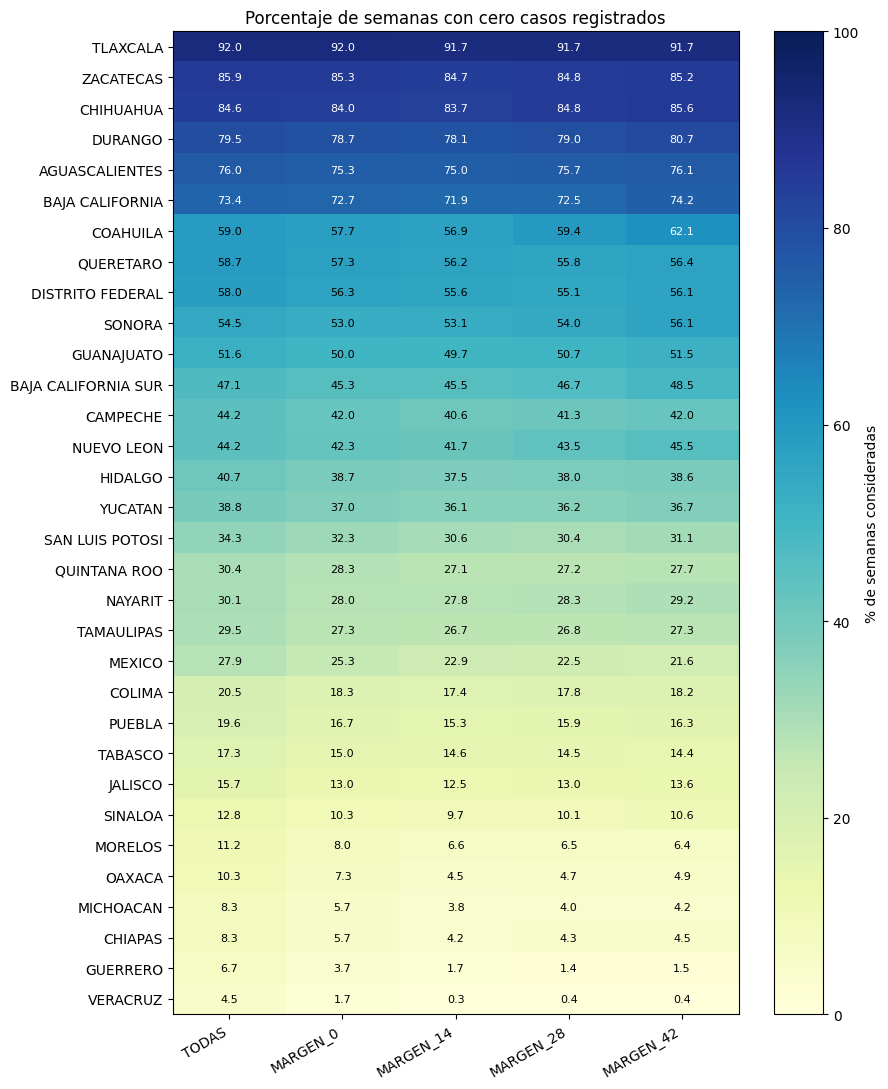

In [28]:
# frecuencia de ceros.
fig, ax = plt.subplots(figsize=(9, 11))
imagen = ax.imshow(
    porcentajes_ceros.to_numpy(),
    cmap="YlGnBu", vmin=0, vmax=100, aspect="auto",
)
ax.set_xticks(range(len(escenarios)))
ax.set_xticklabels(list(escenarios), rotation=30, ha="right")
ax.set_yticks(range(len(orden_estados)))
ax.set_yticklabels(orden_estados)
for i, j in np.ndindex(porcentajes_ceros.shape):
    valor = porcentajes_ceros.iloc[i, j]
    ax.text(
        j, i, f"{valor:.1f}", ha="center", va="center",
        fontsize=8, color="white" if valor > 60 else "black",
    )
ax.set_title("Porcentaje de semanas con cero casos registrados")
fig.colorbar(imagen, ax=ax, label="% de semanas consideradas")
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_05_porcentaje_semanas_cero_por_estado.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

Cada celda muestra el porcentaje de semanas consideradas que tienen cero confirmados registrados para un estado y escenario.

Los estados difieren ampliamente: algunos tienen ceros en la mayoría de las semanas y otros registran confirmados con mayor frecuencia.

Un cero significa que la base analítica no contiene confirmados para esa semana y estado. No demuestra ausencia de infección o de transmisión, ni identifica la causa de la falta de registros.

Comparar columnas permite revisar cuánto cambia la proporción al aplicar las máscaras. Los porcentajes relativamente similares indican poca sensibilidad de este resumen a los márgenes evaluados; no prueban que los ceros sean correctos ni que los datos estén consolidados.

La frecuencia de ceros ayuda a describir los datos y anticipar dificultades de evaluación, pero no basta para elegir un modelo con inflación de ceros.

### Importancia

* **Caracterización del perfil epidemiológico regional:** Permite diferenciar con precisión entre estados con transmisión endémica continua (donde el dengue está presente la mayor parte del año y los ceros son escasos) y estados con transmisión esporádica o baja (donde predominan ampliamente las semanas sin casos).
* **Prevención de sesgos en el modelado predictivo:** La alta frecuencia de ceros en numerosas entidades advierte sobre los retos estadísticos al entrenar modelos de pronóstico o clústeres. Conocer esta proporción ayuda a elegir adecuadamente las métricas de evaluación y las estructuras de modelos de conteo (como modelos de Poisson o binomiales negativas con inflación de ceros).
* **Evaluación de la estabilidad ante cortes temporales:** Demuestra que la proporción de semanas con ceros se mantiene relativamente estable a lo largo de los diferentes márgenes de exclusión evaluados, validando que los ajustes por inmadurez de datos no alteran de forma artificial la estructura de ceros endémicos de cada estado.

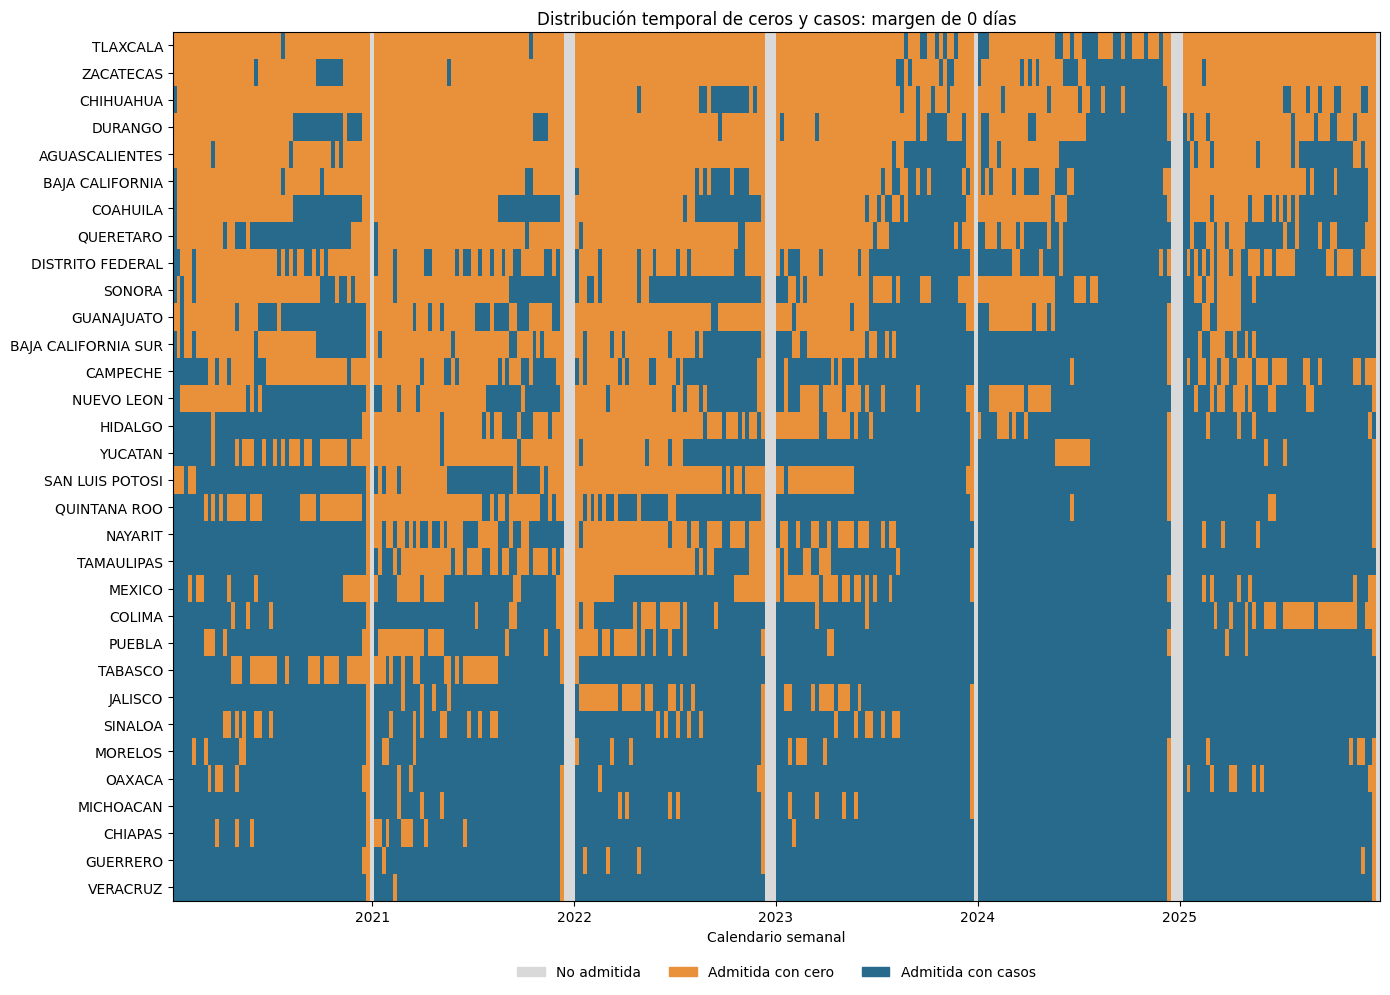

In [29]:
# conservar todas las semanas y distinguir las exclusiones.
valores = casos_estudio.loc[:, orden_estados].to_numpy()
categorias = np.where(
    mascaras["MARGEN_0"].to_numpy()[:, None],
    np.where(valores == 0, 1, 2),
    0,
)

fig, ax = plt.subplots(figsize=(14, 10))
ax.pcolormesh(
    bordes_x, np.arange(len(orden_estados) + 1),
    categorias.T,
    cmap=ListedColormap(["#D9D9D9", "#E8913A", "#276A8B"]),
    norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3),
    shading="flat",
)
ax.set_yticks(np.arange(len(orden_estados)) + 0.5)
ax.set_yticklabels(orden_estados)
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Distribución temporal de ceros y casos: margen de 0 días")
ax.set_xlabel("Calendario semanal")
ax.legend(
    handles=[
        Patch(color="#D9D9D9", label="No admitida"),
        Patch(color="#E8913A", label="Admitida con cero"),
        Patch(color="#276A8B", label="Admitida con casos"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, -0.06),
    ncol=3, frameon=False,
)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_06_distribucion_temporal_ceros_por_estado.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


Cada fila corresponde a un estado y cada rectángulo a una semana. Se utiliza el margen de 0 días como referencia descriptiva.

- **Azul:** semana admitida con confirmados registrados.
- **Naranja:** semana admitida con cero confirmados.
- **Gris:** semana no admitida.

La figura permite localizar periodos con registros positivos y rachas de ceros. Una semana no admitida interrumpe el segmento observado; no debe contarse como cero ni unir las rachas situadas a ambos lados.

Los rectángulos azules indican presencia de registros, no su magnitud: una semana con un caso y otra con cientos reciben el mismo color.

Esta visualización describe continuidad e intermitencia de confirmados registrados. No demuestra transmisión local continua ni permite distinguir ceros reales de posibles problemas de registro.

### Importancia

* **Identificación de patrones endémicos y estacionales:** Permite visualizar con claridad qué estados sufren de transmisión continua y perenne (como Veracruz o Guerrero, con una presencia masiva de franjas azules) frente a aquellos con transmisión intermitente, estacional o esporádica.
* **Mapeo visual de años epidémicos:** Facilita la identificación de picos históricos a nivel nacional (por ejemplo, el incremento de franjas azules en la mayor parte de los estados durante los años de alta transmisión como 2023 y 2024).
* **Diagnóstico para el diseño de modelos:** Ofrece una perspectiva directa de la escasez o abundancia de datos positivos por estado, lo cual es vital para decidir si un modelo de pronóstico debe aplicarse de forma global, regional o de manera individual para cada entidad según su nivel de actividad epidemiológica.

## 4.1. Magnitud, variabilidad e incidencia

Los casos y la incidencia permiten comparar aspectos distintos:

- **Casos:** cantidad registrada de enfermedad.
- **Incidencia:** casos por 100,000 habitantes, considerando la población.

Calcularemos media, mediana, percentil 95 y máximo semanal.
El percentil 95 indica un valor por debajo del cual queda aproximadamente
el 95 % de las observaciones.


Para una media positiva calculamos:

$$
D=\frac{\text{varianza muestral}}{\text{media}}.
$$

- **$D\approx1$:** varianza y media tienen magnitudes similares.
- **$D>1$:** la varianza supera la media.
- **$D<1$:** la varianza es menor que la media.

Si la media es cero, el cociente se deja sin definir.

Una distribución de Poisson con parámetro fijo tiene igual media y varianza. Sin embargo, observar un cociente cercano a uno no demuestra que los datos sigan esa distribución, sean independientes o tengan una tasa constante.

Del mismo modo, un cociente elevado describe dispersión marginal, pero no demuestra sobredispersión condicional de un modelo. Al reunir varios años, la estacionalidad, los brotes y los cambios de nivel también pueden aumentar la varianza.

Utilizaremos este cociente como diagnóstico descriptivo. La elección de un modelo requiere ajuste, revisión de sus supuestos y evaluación temporal.



No es una prueba de dispersión de un modelo Poisson: mezcla brotes,
estacionalidad y cambios entre años.

### Figuras

- **07:** media y varianza de los casos en escala logarítmica.
- **08:** trayectorias de incidencia de ocho estados ilustrativos.
- **09:** incidencia media semanal por estado y año de etiqueta.

Usaremos el margen de 0 días como referencia descriptiva.
Las semanas excluidas aparecerán como huecos en las trayectorias.

Los promedios por año incluyen ceros y utilizan cantidades diferentes
de semanas admitidas. No son incidencias acumuladas de años completos.

Los paneles de trayectorias tendrán escalas verticales independientes.
El mapa anual usará una escala de color no lineal para distinguir valores
pequeños; sus anotaciones mostrarán los valores originales.

Estos resúmenes de 2020–2025 describen los datos. No se utilizarán para
construir agrupamientos o transformaciones de entrenamiento que incorporen
información de años posteriores.

In [32]:
# Resúmenes de casos para los cinco escenarios.
tablas_magnitud = []

for escenario, mascara in escenarios.items():
    datos = casos_estudio.loc[mascara]
    tabla = pd.DataFrame({
        "SEMANAS": len(datos),
        "MEDIA": datos.mean(),
        "MEDIANA": datos.median(),
        "VARIANZA": datos.var(ddof=1),
        "P95": datos.quantile(0.95),
        "MAXIMO": datos.max(),
    })
    tabla["VARIANZA_SOBRE_MEDIA"] = (
        tabla["VARIANZA"] / tabla["MEDIA"].replace(0, np.nan)
    )
    tabla["ESCENARIO"] = escenario
    tablas_magnitud.append(tabla.rename_axis("ESTADO").reset_index())

resumen_magnitud = pd.concat(tablas_magnitud, ignore_index=True)
magnitud_ref = (
    resumen_magnitud.loc[resumen_magnitud["ESCENARIO"].eq("MARGEN_0")]
    .set_index("ESTADO").sort_values("MEDIA", ascending=False)
)

# Incidencia: mismos ceros que en casos, sin aplicar nuevas transformaciones.
assert casos_estudio.eq(0).equals(incidencia_estudio.eq(0))
admision_ref = mascaras["MARGEN_0"]
incidencia_ref = incidencia_estudio.loc[admision_ref]

resumen_incidencia = pd.DataFrame({
    "MEDIA": incidencia_ref.mean(),
    "MEDIANA": incidencia_ref.median(),
    "P95": incidencia_ref.quantile(0.95),
    "MAXIMO": incidencia_ref.max(),
    "PRIMERA_FECHA_MAXIMO": incidencia_ref.idxmax().where(
        incidencia_ref.max().gt(0)
    ),
}).rename_axis("ESTADO").sort_values("MEDIA", ascending=False)

incidencia_anual = (
    incidencia_ref.groupby(incidencia_ref.index.year).mean().T
    .reindex(index=resumen_incidencia.index, columns=ANIOS)
)
incidencia_anual.columns.name = "ANIO_ETIQUETA"
n_semanas_anuales = incidencia_ref.groupby(
    incidencia_ref.index.year
).size()

print("Casos semanales: margen de 0 días")
display(magnitud_ref.drop(columns="ESCENARIO").round(2))
print("\nIncidencia semanal por 100,000 habitantes: margen de 0 días")
display(resumen_incidencia.round(3))
print("\nIncidencia media semanal por año de etiqueta:")
display(incidencia_anual.round(3))

Casos semanales: margen de 0 días


,SEMANAS,MEDIA,MEDIANA,VARIANZA,P95,MAXIMO,VARIANZA_SOBRE_MEDIA
ESTADO,,,,,,,
JALISCO,300,97.29,12.5,63499.61,602.05,1643,652.66
VERACRUZ,300,83.16,32.5,19192.78,366.90,826,230.79
NUEVO LEON,300,43.90,1.0,20098.80,396.95,841,457.87
MORELOS,300,41.35,10.0,6562.49,241.15,441,158.69
GUERRERO,300,41.26,12.0,5959.03,189.05,538,144.44
MICHOACAN,300,38.52,11.0,3995.57,169.40,408,103.72
YUCATAN,300,38.27,2.0,19432.12,193.45,1018,507.76
CHIAPAS,300,32.95,12.0,2514.19,153.50,234,76.30
PUEBLA,300,32.26,6.5,3640.80,169.10,318,112.85



Incidencia semanal por 100,000 habitantes: margen de 0 días


,MEDIA,MEDIANA,P95,MAXIMO,PRIMERA_FECHA_MAXIMO
ESTADO,,,,,
COLIMA,2.784,0.401,16.829,37.907,2024-09-01
MORELOS,2.032,0.498,11.874,21.577,2024-08-11
NAYARIT,1.816,0.232,9.672,31.464,2024-09-01
YUCATAN,1.561,0.081,7.888,41.511,2023-09-10
BAJA CALIFORNIA SUR,1.537,0.118,9.413,22.346,2024-10-06
GUERRERO,1.144,0.333,5.242,14.917,2024-01-07
QUINTANA ROO,1.139,0.190,7.380,9.804,2023-10-22
TABASCO,1.125,0.408,5.741,10.306,2023-10-08
JALISCO,1.110,0.144,6.825,18.626,2024-10-13



Incidencia media semanal por año de etiqueta:


ANIO_ETIQUETA,2020,2021,2022,2023,2024,2025
ESTADO,,,,,,
COLIMA,0.974,0.390,0.404,1.556,13.230,0.115
MORELOS,0.595,0.577,0.594,4.028,6.207,0.125
NAYARIT,1.269,0.073,0.014,0.380,8.385,0.743
YUCATAN,0.112,0.002,0.357,8.300,0.283,0.150
BAJA CALIFORNIA SUR,0.072,0.020,0.214,1.625,5.799,1.462
GUERRERO,0.311,0.180,0.481,1.957,3.654,0.252
QUINTANA ROO,0.208,0.012,0.524,4.812,0.943,0.247
TABASCO,0.305,0.068,0.789,2.025,2.890,0.644
JALISCO,1.234,0.043,0.017,0.215,4.630,0.495


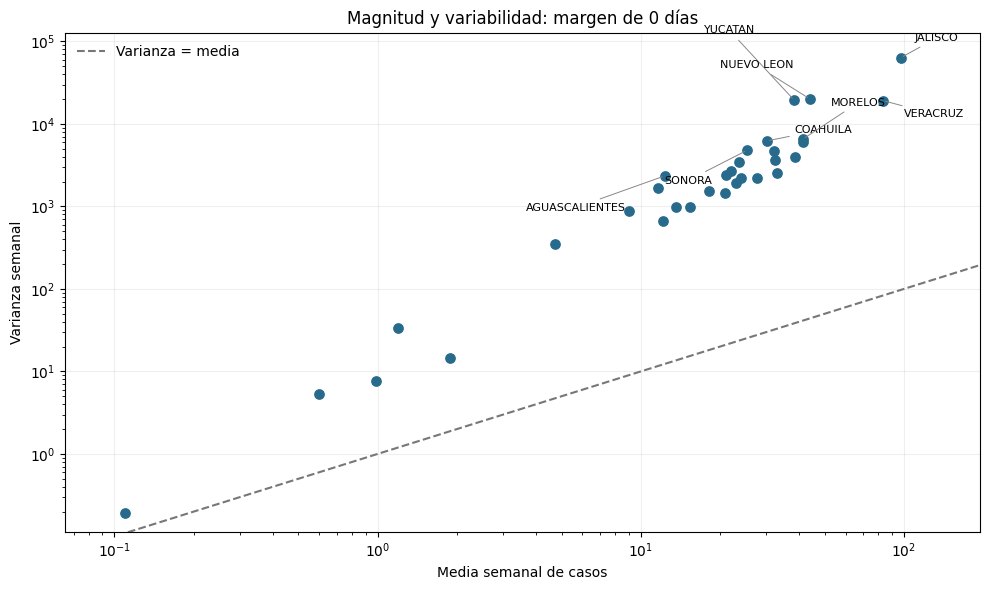

In [37]:
#  límites independientes y etiquetas separadas.
graficables = magnitud_ref.loc[
    magnitud_ref["MEDIA"].gt(0) & magnitud_ref["VARIANZA"].gt(0)
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    graficables["MEDIA"], graficables["VARIANZA"],
    color="#276A8B", s=45, zorder=3,
)

limites_x = (
    graficables["MEDIA"].min() / 1.7,
    graficables["MEDIA"].max() * 2,
)
limites_y = (
    graficables["VARIANZA"].min() / 1.7,
    graficables["VARIANZA"].max() * 2,
)

ax.plot(
    limites_x, limites_x, "--", color="#777777",
    label="Varianza = media",
)

desplazamientos = {
    "JALISCO": (10, 12),
    "YUCATAN": (-65, 48),
    "NUEVO LEON": (-65, 22),
    "VERACRUZ": (15, -12),
    "COAHUILA": (20, 6),
    "AGUASCALIENTES": (-100, -25),
    "SONORA": (-60, -24),
    "MORELOS": (20, 24),
}

for estado, fila in graficables.nlargest(
    8, "VARIANZA_SOBRE_MEDIA"
).iterrows():
    ax.annotate(
        estado,
        xy=(fila["MEDIA"], fila["VARIANZA"]),
        xytext=desplazamientos.get(estado, (10, 10)),
        textcoords="offset points",
        fontsize=8,
        arrowprops={"arrowstyle": "-", "color": "#888888", "lw": 0.7},
    )

ax.set(
    xscale="log", yscale="log",
    xlim=limites_x, ylim=limites_y,
    xlabel="Media semanal de casos",
    ylabel="Varianza semanal",
    title="Magnitud y variabilidad: margen de 0 días",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_07_media_varianza_casos_semanales.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

Cada punto representa un estado:

- **Eje horizontal:** media semanal de casos.
- **Eje vertical:** varianza semanal.
- **Línea discontinua:** referencia donde varianza y media son iguales.

Ambos ejes son logarítmicos: distancias iguales representan cambios multiplicativos, no incrementos absolutos iguales.

Todos los estados tienen varianza superior a la media, aunque la diferencia es mucho mayor en algunos. Esto muestra una dispersión elevada del conjunto de semanas, compatible con series que combinan periodos de poca actividad y brotes intensos.

La figura no permite descartar por sí sola una regresión Poisson ni seleccionar una binomial negativa. La dispersión de un modelo debe revisarse después de considerar sus predictores y su estructura temporal.

### Importancia

* **Evidencia visual de la sobredispersión (*overdispersion*):** La figura demuestra empíricamente que la varianza de los casos de dengue es varios órdenes de magnitud mayor que su media en prácticamente todas las entidades federativas. Esto significa que los datos no son estables ni siguen un comportamiento aleatorio simple.


* **Fundamentación estadística para la selección de modelos:** Al comprobar que los datos no cumplen con la premisa de que la varianza es igual a la media (distribución de Poisson), se descartan los modelos de conteo tradicionales o simples.


* **Guía para técnicas avanzadas de pronóstico:** Justifica formalmente la necesidad de implementar modelos estadísticos y de aprendizaje automático más flexibles y robustos —como la **regresión binomial negativa** o arquitecturas especializadas— capaces de tolerar y modelar de manera adecuada la alta variabilidad y dispersión inherentes a la dinámica de transmisión del dengue.

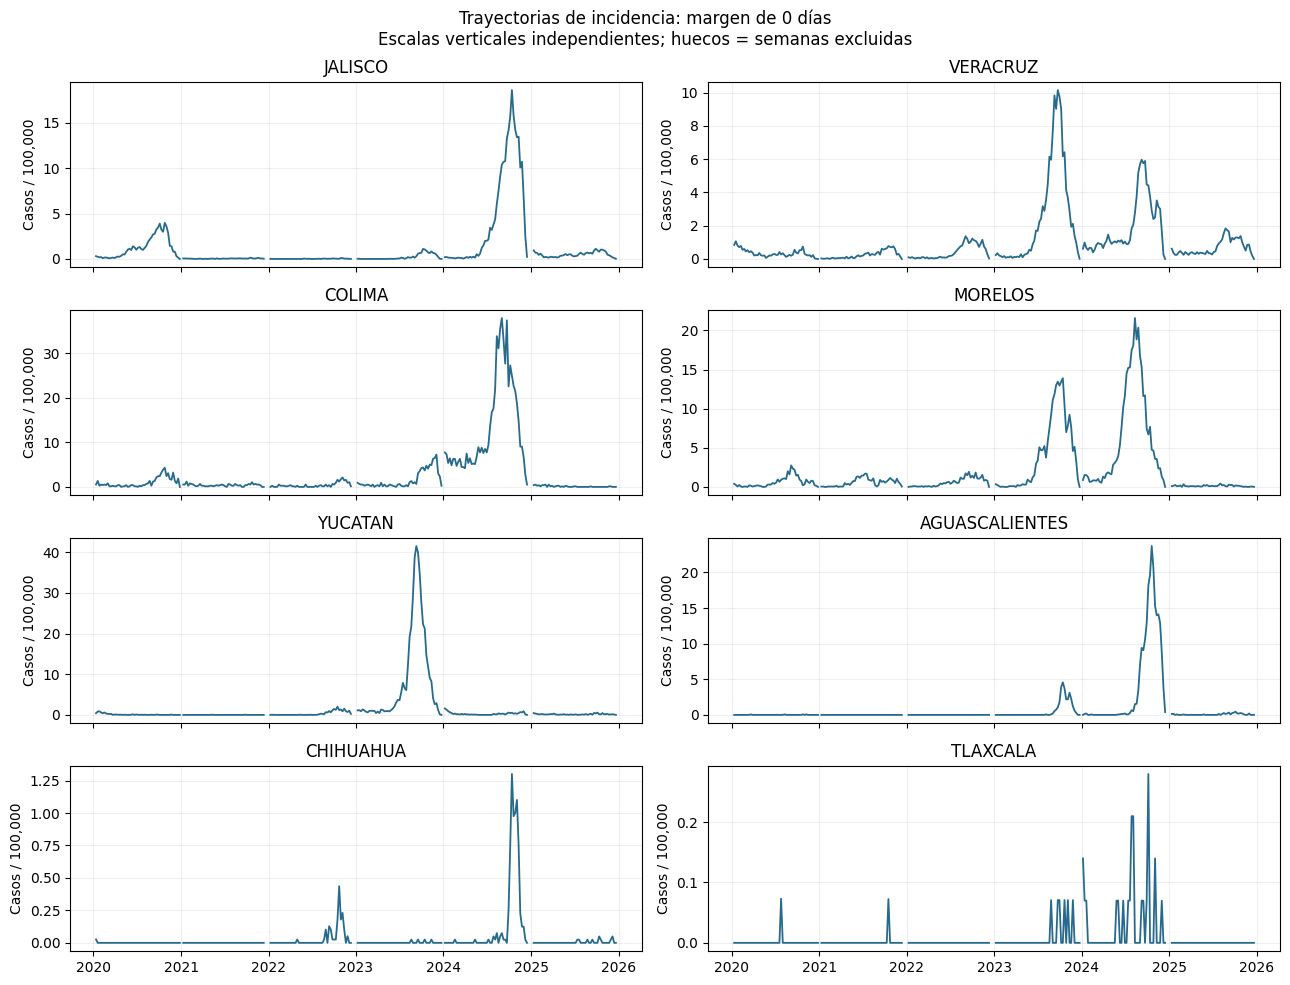

In [35]:
incidencia_visual = incidencia_estudio.copy()
incidencia_visual.loc[~admision_ref, :] = np.nan
ESTADOS_EJEMPLO = [
    "JALISCO", "VERACRUZ", "COLIMA", "MORELOS",
    "YUCATAN", "AGUASCALIENTES", "CHIHUAHUA", "TLAXCALA",
]
fig, axes = plt.subplots(4, 2, figsize=(13, 10), sharex=True)
for ax, estado in zip(axes.flat, ESTADOS_EJEMPLO):
    ax.plot(
        incidencia_visual.index, incidencia_visual[estado],
        color="#276A8B", linewidth=1.3,
    )
    ax.set(title=estado, ylabel="Casos / 100,000")
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle(
    "Trayectorias de incidencia: margen de 0 días\n"
    "Escalas verticales independientes; huecos = semanas excluidas"
)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig_08_trayectorias_incidencia_estados_ejemplo.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


Los paneles muestran la incidencia semanal registrada por 100,000 habitantes en ocho estados ilustrativos, utilizando el margen de 0 días.

Las trayectorias permiten comparar fechas de aumento, picos y periodos de menor actividad. Los huecos representan semanas no admitidas y no deben interpretarse como ceros.

Cada panel tiene una escala vertical independiente. Para comparar magnitudes entre estados debemos leer los valores de sus ejes, no solo la altura visual de los picos.

La incidencia considera el tamaño poblacional utilizado como denominador. No mide directamente la severidad de la enfermedad ni elimina diferencias de edad, vigilancia, diagnóstico o registro entre estados.

Estas trayectorias son descriptivas; no se utilizarán para construir predictores o agrupamientos que incorporen información posterior al entrenamiento.

### Importancia

* **Visualización de la heterogeneidad epidemiológica:** Permite apreciar de inmediato que el comportamiento del dengue no es homogéneo en el país; mientras algunos estados registran tasas masivas superiores a 20 o 40 casos por cada 100,000 habitantes, otros se mantienen cercanos a cero la mayor parte del tiempo.


* **Estandarización justa mediante tasas de incidencia:** Al emplear la incidencia por 100,000 habitantes en lugar de conteos absolutos, normaliza el tamaño poblacional de cada entidad, permitiendo comparar de forma equitativa la intensidad del riesgo y la severidad de los brotes entre estados pequeños y grandes.


* **Identificación de años epidémicos críticos:** Facilita la detección visual de los años con mayor actividad de transmisión a nivel regional (como los picos epidémicos nacionales ocurridos en los ciclos 2023–2024), lo cual es indispensable para que los algoritmos de pronóstico aprendan patrones estacionales y de intensidad reales.

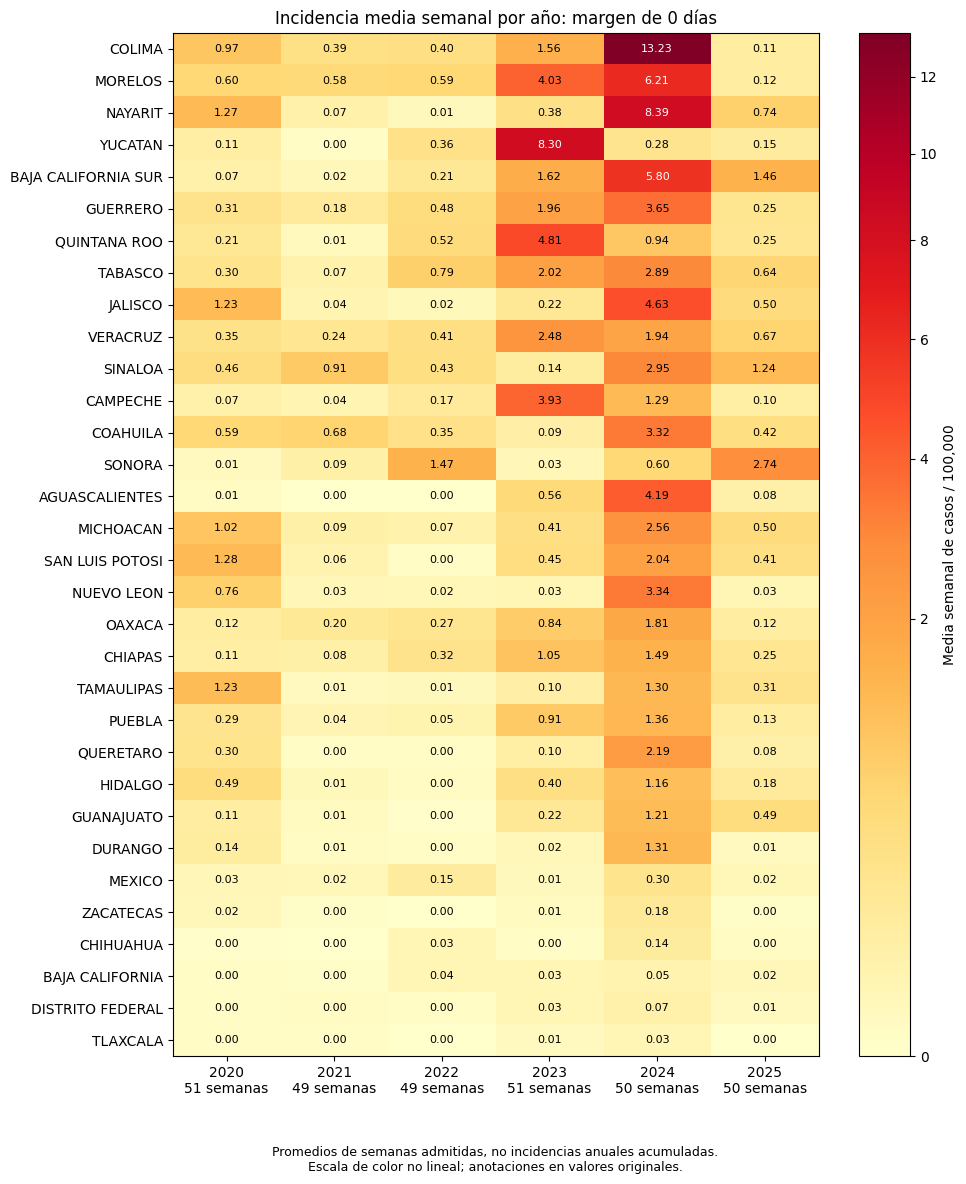

In [36]:
# promedios de las semanas admitidas, incluyendo ceros.
norma = PowerNorm(
    gamma=0.45, vmin=0, vmax=max(float(incidencia_anual.max().max()), 1e-9)
)
fig, ax = plt.subplots(figsize=(10, 12))
imagen = ax.imshow(
    incidencia_anual.to_numpy(), cmap="YlOrRd",
    norm=norma, aspect="auto",
)
ax.set_xticks(range(len(ANIOS)))
ax.set_xticklabels([
    f"{anio}\n{n_semanas_anuales.loc[anio]} semanas" for anio in ANIOS
])
ax.set_yticks(range(len(incidencia_anual)))
ax.set_yticklabels(incidencia_anual.index)
for i, j in np.ndindex(incidencia_anual.shape):
    valor = incidencia_anual.iloc[i, j]
    ax.text(
        j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
        color="white" if norma(valor) > 0.65 else "black",
    )
ax.set_title("Incidencia media semanal por año: margen de 0 días")
fig.colorbar(imagen, ax=ax, label="Media semanal de casos / 100,000")
fig.text(
    0.5, 0.02,
    "Promedios de semanas admitidas, no incidencias anuales acumuladas.\n"
    "Escala de color no lineal; anotaciones en valores originales.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(
    FIG_DIR / "fig_09_incidencia_media_semanal_por_anio.png",
    dpi=300, bbox_inches="tight",
)
plt.show()



Cada celda contiene la incidencia media semanal de un estado durante las semanas admitidas de un año de etiqueta, con margen de 0 días.

Los valores muestran diferencias entre estados y años. En muchos estados, 2024 presenta el promedio más alto, aunque existen excepciones.

Las columnas utilizan cantidades y conjuntos diferentes de semanas admitidas. Por ello, los resultados describen los periodos seleccionados y no deben interpretarse como incidencias acumuladas de años completos.

La escala de color es no lineal para facilitar la lectura de valores pequeños. Las cifras anotadas conservan los valores originales.

Considerar la población mejora la comparación respecto a los conteos absolutos, pero no elimina todas las diferencias demográficas o de registro.

### Importancia

* **Identificación del año epidémico pico:** Permite observar de manera global y comparativa cómo el año **2024** concentró de forma generalizada las incidencias semanales más altas en la gran mayoría de los estados en comparación con los años previos (2020–2023).


* **Evolución interanual del riesgo:** Facilita el seguimiento de la persistencia o brotes esporádicos por entidad; muestra qué estados mantienen transmisión endémica constante todos los años (como Colima, Morelos o Guerrero) frente a aquellos donde los picos epidémicos ocurren de manera intermitente cada varios años.
* **Validación de la estandarización poblacional:** Al representar medias semanales de incidencia por 100,000 habitantes, asegura una lectura normalizada que impide sesgos derivados de las diferencias demográficas entre estados, guiando de manera óptima la selección de datos para el entrenamiento de modelos predictivos espaciotemporales.

## 5. Calendario de evaluación y antecedentes de casos

Para evaluar un pronóstico debemos respetar el orden del tiempo:

| Etapa | Años | Propósito |
|---|---|---|
| Entrenamiento | 2020–2023 | Aprender las relaciones entre predictores y casos. |
| Validación | 2024 | Comparar alternativas y elegir la configuración. |
| Prueba | 2025 | Evaluar la configuración elegida. |

Como ya exploramos 2025, lo consideramos una evaluación temporal reservada, aunque no completamente ciega. 

### Por qué utilizamos una partición cronológica

Separaremos entrenamiento, validación y prueba respetando el orden del tiempo. Esta es una partición cronológica en tres bloques, no una validación cruzada temporal con múltiples particiones.

- **Entrenamiento, 2020–2023:** ajustar los modelos y las transformaciones que deban aprenderse de los datos.
- **Validación, 2024:** comparar alternativas y elegir la configuración.
- **Prueba, 2025:** evaluar la configuración elegida sin utilizar sus resultados para reajustarla.

Un reparto aleatorio podría mezclar pasado y futuro y colocar semanas cercanas en diferentes conjuntos. Esto puede producir una evaluación demasiado optimista para la pregunta de pronóstico.

La actividad elevada de 2024 será una condición relevante de la validación, pero no garantiza que una configuración funcione bien en otros años.

Como 2025 ya fue explorado durante el diagnóstico, su evaluación no es completamente ciega.

Además, separar los años no resuelve por sí solo la disponibilidad histórica: utilizamos archivos retrospectivos y todavía debemos definir qué información podría conocerse en cada origen.


### ¿Qué significa cada pronóstico?

La **fecha origen** representa el momento desde el que se pronostica. La **fecha objetivo** identifica el domingo que cierra la semana que queremos predecir.

Evaluaremos dos horizontes:

- **1 semana:** predecir los casos de la semana que termina una semana después del origen.
- **4 semanas:** predecir los casos de la semana que termina cuatro semanas después del origen. No es la suma de las cuatro semanas.

La etapa se asigna según la fecha objetivo. Por ello, un objetivo de enero puede tener su origen en diciembre del año anterior.

### ¿Qué antecedentes revisaremos?

Para cada origen comprobaremos cuatro semanas de casos:

- Rezago 0: semana que termina en el origen.
- Rezago 1: una semana antes del origen.
- Rezago 2: dos semanas antes.
- Rezago 3: tres semanas antes.

Cada antecedente debe estar admitido por la máscara del margen correspondiente. Buscaremos las fechas exactas en el calendario: eliminar semanas y después desplazar filas podría confundir semanas consecutivas con semanas separadas.

Conservaremos todos los candidatos y señalaremos cuáles cumplen esta condición.

**Límite de esta revisión:** una semana admitida retrospectivamente no garantiza que sus casos estuvieran publicados en la fecha origen. Antes de modelar debemos definir la regla de disponibilidad, especialmente para el rezago 0.

In [39]:
HORIZONTES = [1, 4]
REZAGOS_CASOS = [0, 1, 2, 3]
ETAPAS = ["ENTRENAMIENTO", "VALIDACION", "PRUEBA"]

# La etapa depende del año de la fecha objetivo.
etapa_por_anio = {
    2020: "ENTRENAMIENTO", 2021: "ENTRENAMIENTO",
    2022: "ENTRENAMIENTO", 2023: "ENTRENAMIENTO",
    2024: "VALIDACION", 2025: "PRUEBA",
}
calendario_estudio["ETAPA"] = (
    calendario_estudio.index.year.map(etapa_por_anio)
)
assert calendario_estudio["ETAPA"].notna().all()

# Resumen del calendario y de las máscaras por etapa.
resumen_etapas = pd.DataFrame([
    {
        "ETAPA": etapa,
        "PRIMERA_ETIQUETA": grupo.index.min(),
        "ULTIMA_ETIQUETA": grupo.index.max(),
        "SEMANAS_CALENDARIO": len(grupo),
        **mascaras.loc[grupo.index].sum().astype(int).to_dict(),
    }
    for etapa in ETAPAS
    for grupo in [
        calendario_estudio.loc[calendario_estudio["ETAPA"].eq(etapa)]
    ]
]).set_index("ETAPA")

# Crear candidatos y revisar antecedentes sin comprimir el calendario.
bloques = []

for margen in MARGENES:
    mascara = mascaras[f"MARGEN_{margen}"]

    for etapa in ["VALIDACION", "PRUEBA"]:
        objetivos = calendario_estudio.index[
            calendario_estudio["ETAPA"].eq(etapa) & mascara
        ]

        for horizonte in HORIZONTES:
            bloque = pd.DataFrame({
                "ETAPA_OBJETIVO": etapa,
                "MARGEN_DIAS": margen,
                "HORIZONTE_SEMANAS": horizonte,
                "FECHA_OBJETIVO": objetivos,
                "FECHA_ORIGEN": objetivos - pd.Timedelta(weeks=horizonte),
            })

            for rezago in REZAGOS_CASOS:
                fechas = (
                    bloque["FECHA_ORIGEN"]
                    - pd.Timedelta(weeks=rezago)
                )
                bloque[f"CASOS_REZAGO_{rezago}_ADMITIDO"] = (
                    mascara.reindex(pd.DatetimeIndex(fechas))
                    .fillna(False).astype(bool).to_numpy()
                )

            columnas = [
                f"CASOS_REZAGO_{r}_ADMITIDO" for r in REZAGOS_CASOS
            ]
            bloque["N_ANTECEDENTES_ADMITIDOS"] = (
                bloque[columnas].sum(axis=1)
            )
            bloque["CUATRO_ANTECEDENTES_ADMITIDOS"] = (
                bloque[columnas].all(axis=1)
            )
            bloques.append(bloque)

candidatos = pd.concat(bloques, ignore_index=True)

claves = ["ETAPA_OBJETIVO", "MARGEN_DIAS", "HORIZONTE_SEMANAS"]
assert not candidatos.duplicated(claves + ["FECHA_OBJETIVO"]).any()
assert (
    (candidatos["FECHA_OBJETIVO"] - candidatos["FECHA_ORIGEN"]).dt.days
    == 7 * candidatos["HORIZONTE_SEMANAS"]
).all()

resumen_candidatos = candidatos.groupby(claves, sort=False).agg(
    CANDIDATOS=("FECHA_OBJETIVO", "size"),
    ORIGENES_ADMITIDOS=("CASOS_REZAGO_0_ADMITIDO", "sum"),
    CON_CUATRO_ANTECEDENTES=("CUATRO_ANTECEDENTES_ADMITIDOS", "sum"),
).reset_index()

print("Calendario de evaluación:")
display(resumen_etapas)

print("\nCandidatos y admisión retrospectiva de antecedentes:")
display(resumen_candidatos)

print(f"\nCandidatos conservados: {len(candidatos):,}")
print("No se ha seleccionado un margen ni ajustado modelos.")

Calendario de evaluación:


,PRIMERA_ETIQUETA,ULTIMA_ETIQUETA,SEMANAS_CALENDARIO,MARGEN_0,MARGEN_14,MARGEN_28,MARGEN_42
ETAPA,,,,,,,
ENTRENAMIENTO,2020-01-12,2023-12-31,208,200,192,184,176
VALIDACION,2024-01-07,2024-12-29,52,50,48,46,44
PRUEBA,2025-01-05,2025-12-28,52,50,48,46,44



Candidatos y admisión retrospectiva de antecedentes:


,ETAPA_OBJETIVO,MARGEN_DIAS,HORIZONTE_SEMANAS,CANDIDATOS,ORIGENES_ADMITIDOS,CON_CUATRO_ANTECEDENTES
0,VALIDACION,0,1,50,49,46
1,VALIDACION,0,4,50,49,46
2,PRUEBA,0,1,50,49,46
3,PRUEBA,0,4,50,47,44
4,VALIDACION,14,1,48,47,44
5,VALIDACION,14,4,48,45,42
6,PRUEBA,14,1,48,47,44
7,PRUEBA,14,4,48,44,41
8,VALIDACION,28,1,46,45,42
9,VALIDACION,28,4,46,42,39



Candidatos conservados: 752
No se ha seleccionado un margen ni ajustado modelos.


## 6. Comprobación de las variables meteorológicas

Antes de combinar clima y dengue, debemos comprobar que ambos utilizan las mismas fechas y estados.

También verificaremos cómo se construyó cada valor semanal a partir de los datos diarios:

| Variable | Operación dentro de la semana |
|---|---|
| T2M: temperatura media | Media |
| T2M_MAX: temperatura máxima diaria | Máximo |
| T2M_MIN: temperatura mínima diaria | Mínimo |
| RH2M: humedad relativa | Media |
| PRECTOTCORR: precipitación | Suma |
| ALLSKY_SFC_SW_DWN: radiación solar | Media |
| WS10M: velocidad del viento | Media |
| GWETTOP: humedad superficial del suelo | Media |
| EVLAND: evaporación terrestre | Media |

Por ejemplo, la precipitación semanal representa el acumulado de los siete días. La temperatura máxima semanal representa el mayor valor de T2M_MAX durante esos días.

### ¿Qué comprobaremos?

1. Las nueve matrices semanales están alineadas con los casos.
2. Cada semana del periodo de estudio tiene siete valores diarios por estado y variable.
3. La agregación reconstruida coincide con la matriz semanal guardada.

Trabajaremos con semanas de lunes a domingo. Mantendremos el calendario completo del clima, aunque alguna semana de casos no esté admitida: excluir casos no implica que falten datos meteorológicos.

**Alcance:** estos datos representan un punto geográfico por estado. La comprobación valida su estructura y agregación, pero no demuestra que ese punto describa todo el clima del estado ni que los datos estuvieran disponibles en tiempo real.

In [41]:
# Localizar el directorio meteorológico.
CLIMA_DIR = next(
    (ruta for ruta in [BASE / "nasa_power", PROYECTO_DIR / "nasa_power"]
     if (ruta / "matrices_semanales").is_dir()),
    None,
)
assert CLIMA_DIR is not None, "No se encontró nasa_power/matrices_semanales."

operaciones_clima = {
    "ALLSKY_SFC_SW_DWN": "mean",
    "EVLAND": "mean",
    "GWETTOP": "mean",
    "PRECTOTCORR": "sum",
    "RH2M": "mean",
    "T2M_MAX": "max",
    "T2M_MIN": "min",
    "T2M": "mean",
    "WS10M": "mean",
}

# Cargar matrices y comprobar su alineación.
matrices_clima = {}

for variable in operaciones_clima:
    ruta = CLIMA_DIR / "matrices_semanales" / (
        f"{variable.lower()}_semanal_por_estado_2020_2026.csv"
    )
    matriz = cargar_matriz(ruta)

    assert matriz.index.equals(casos.index), f"Fechas distintas: {variable}"
    assert matriz.columns.equals(casos.columns), f"Estados distintos: {variable}"
    assert not matriz.eq(-999).any().any(), f"Valor -999: {variable}"

    matrices_clima[variable] = matriz

# Reconstruir las semanas desde los archivos diarios.
archivos_diarios = sorted(
    (CLIMA_DIR / "diario_por_estado").glob("power_diario_*.csv")
)
assert len(archivos_diarios) == len(estados), "Revisar archivos diarios."

revision_diaria = []
comparacion_clima = []
estados_revisados = set()

for ruta in archivos_diarios:
    diario = pd.read_csv(ruta, encoding="utf-8-sig")
    fechas = pd.to_datetime(diario["FECHA"], errors="raise")

    assert fechas.notna().all() and fechas.is_unique, ruta.name
    assert fechas.eq(fechas.dt.normalize()).all(), ruta.name
    assert diario["ESTADO"].notna().all(), ruta.name

    nombres = diario["ESTADO"].astype(str).str.strip().unique()
    assert len(nombres) == 1, f"Más de un estado: {ruta.name}"
    estado = nombres[0]
    assert estado in estados and estado not in estados_revisados, estado
    estados_revisados.add(estado)

    valores = diario[list(operaciones_clima)].apply(
        pd.to_numeric, errors="raise"
    )
    assert np.isfinite(valores.to_numpy()).all(), ruta.name
    assert not valores.eq(-999).any().any(), f"Valor -999: {ruta.name}"

    valores.index = pd.DatetimeIndex(fechas, name="FECHA")
    valores = valores.sort_index()

    conteos = valores.resample(
        "W-SUN", closed="right", label="right"
    ).count().reindex(calendario_estudio.index)

    for variable, operacion in operaciones_clima.items():
        reconstruida = valores[variable].resample(
            "W-SUN", closed="right", label="right"
        ).agg(operacion).reindex(calendario_estudio.index)

        guardada = matrices_clima[variable].loc[
            calendario_estudio.index, estado
        ]
        completas = conteos[variable].eq(7)
        coinciden = np.isclose(
            reconstruida.to_numpy(), guardada.to_numpy(),
            rtol=1e-7, atol=1e-6,
        )

        revision_diaria.append({
            "ESTADO": estado,
            "VARIABLE": variable,
            "SEMANAS_REVISADAS": len(conteos),
            "CON_7_VALORES": int(completas.sum()),
        })
        comparacion_clima.append({
            "ESTADO": estado,
            "VARIABLE": variable,
            "OPERACION": operacion,
            "VALORES_COMPARADOS": len(guardada),
            "COINCIDENCIAS": int(coinciden.sum()),
            "ERROR_ABSOLUTO_MAXIMO": float(
                (reconstruida - guardada).abs().max()
            ),
        })

assert estados_revisados == set(estados)

revision_diaria = pd.DataFrame(revision_diaria)
comparacion_clima = pd.DataFrame(comparacion_clima)

assert revision_diaria["CON_7_VALORES"].eq(
    revision_diaria["SEMANAS_REVISADAS"]
).all(), "Hay semanas con cobertura diaria incompleta."

assert comparacion_clima["COINCIDENCIAS"].eq(
    comparacion_clima["VALORES_COMPARADOS"]
).all(), "Hay diferencias en las agregaciones."

resumen_clima = comparacion_clima.groupby(
    ["VARIABLE", "OPERACION"]
).agg(
    ESTADOS=("ESTADO", "nunique"),
    VALORES_COMPARADOS=("VALORES_COMPARADOS", "sum"),
    COINCIDENCIAS=("COINCIDENCIAS", "sum"),
    ERROR_ABSOLUTO_MAXIMO=("ERROR_ABSOLUTO_MAXIMO", "max"),
).reset_index()

print(f"Matrices semanales alineadas: {len(matrices_clima)}")
print(f"Estados con datos diarios comprobados: {len(estados_revisados)}")
print("Todas las semanas de estudio tienen siete valores diarios.")
display(resumen_clima.round(6))

Matrices semanales alineadas: 9
Estados con datos diarios comprobados: 32
Todas las semanas de estudio tienen siete valores diarios.


,VARIABLE,OPERACION,ESTADOS,VALORES_COMPARADOS,COINCIDENCIAS,ERROR_ABSOLUTO_MAXIMO
0,ALLSKY_SFC_SW_DWN,mean,32,9984,9984,0.0
1,EVLAND,mean,32,9984,9984,0.0
2,GWETTOP,mean,32,9984,9984,0.0
3,PRECTOTCORR,sum,32,9984,9984,0.0
4,RH2M,mean,32,9984,9984,0.0
5,T2M,mean,32,9984,9984,0.0
6,T2M_MAX,max,32,9984,9984,0.0
7,T2M_MIN,min,32,9984,9984,0.0
8,WS10M,mean,32,9984,9984,0.0


## 7. Ventanas climáticas y su posición respecto al pronóstico

Una ventana resume varias semanas de clima. Esto permite representar antecedentes recientes y más lejanos mediante pocos predictores.

Tomaremos como referencia la **fecha origen del pronóstico**:

| Ventana | Semanas incluidas respecto al origen |
|---|---|
| t0 | Semana que termina en el origen |
| l1_2 | Una y dos semanas antes |
| l3_6 | De tres a seis semanas antes |
| l7_12 | De siete a doce semanas antes |

Para temperatura y humedad calculamos la **media** de las semanas incluidas. Para precipitación calculamos la **suma**, porque interesa el acumulado durante la ventana.

### ¿Qué verificaremos?

Reconstruiremos las doce ventanas desde las matrices semanales y las compararemos con los archivos guardados. También comprobaremos que sus valores ausentes estén únicamente al comienzo, donde todavía no existen suficientes antecedentes.

Los rezagos se calculan sobre el calendario completo. No eliminaremos semanas intermedias antes de construir las ventanas.

### Evitar información futura

Para pronosticar desde una fecha origen, debemos tomar las ventanas correspondientes a **esa fecha**, no a la fecha objetivo.

Por ejemplo, para predecir una semana situada cuatro semanas después del origen, `t0` describe el clima de la semana que termina en el origen. No describe el clima de la semana que vamos a predecir.

La figura mostrará esta separación. La disponibilidad real de `t0` sigue pendiente de definir: que una semana haya terminado no garantiza que sus datos ya estén publicados.

In [47]:
VENTANAS_DIR = next(
    (ruta for ruta in [
        BASE / "ventanas_climaticas",
        PROYECTO_DIR / "ventanas_climaticas",
    ] if ruta.is_dir()),
    None,
)
assert VENTANAS_DIR is not None, "No se encontró ventanas_climaticas."

familias = {
    "precip": ("PRECTOTCORR", "SUMA"),
    "rh2m": ("RH2M", "MEDIA"),
    "t2m": ("T2M", "MEDIA"),
}
intervalos = {"t0": (0, 0), "l1_2": (1, 2),
              "l3_6": (3, 6), "l7_12": (7, 12)}

ventanas_clima = {}
filas_diccionario = []
filas_revision = []

# Indica qué semanas cuentan con la comprobación diaria de la sección 6.
semanas_verificadas = pd.Series(
    casos.index.isin(calendario_estudio.index), index=casos.index
)

for familia, (variable, operacion) in familias.items():
    semanal = matrices_clima[variable]

    for ventana, (inicio, fin) in intervalos.items():
        predictor = f"{familia}_{ventana}"
        ruta = VENTANAS_DIR / f"{predictor}_por_estado_2020_2026.csv"

        archivo = pd.read_csv(ruta, encoding="utf-8-sig")
        archivo.index = pd.DatetimeIndex(
            pd.to_datetime(archivo.pop("FECHA"), errors="raise"),
            name="FECHA",
        )
        archivo = archivo.apply(pd.to_numeric, errors="raise")

        assert archivo.index.equals(casos.index), predictor
        assert archivo.columns.equals(casos.columns), predictor
        assert not np.isinf(archivo.to_numpy()).any(), predictor
        assert not archivo.eq(-999).any().any(), predictor

        longitud = fin - inicio + 1

        if ventana == "t0":
            reconstruida = semanal.copy()
            verificables = semanas_verificadas.copy()
            operacion_ventana = "IDENTIDAD"
        else:
            desplazada = semanal.shift(inicio)
            rodante = desplazada.rolling(longitud, min_periods=longitud)
            reconstruida = (
                rodante.sum() if operacion == "SUMA" else rodante.mean()
            )
            verificables = (
                semanas_verificadas.astype(float).shift(inicio)
                .rolling(longitud, min_periods=longitud)
                .sum().eq(longitud)
            )
            operacion_ventana = operacion

        # Los valores ausentes deben aparecer en las posiciones esperadas.
        assert archivo.isna().equals(reconstruida.isna()), predictor

        # Tanto la fecha de la ventana como sus antecedentes
        # deben pertenecer al periodo de estudio verificado.
        verificables = verificables & semanas_verificadas

        observado = archivo.loc[verificables].to_numpy()
        esperado = reconstruida.loc[verificables].to_numpy()
        
        coincidencias = np.isclose(
            observado, esperado, rtol=1e-7, atol=1e-6
        )
        assert coincidencias.all(), f"Ventana distinta: {predictor}"

        ventanas_clima[predictor] = archivo
        filas_diccionario.append({
            "PREDICTOR": predictor,
            "VARIABLE_SEMANAL": variable,
            "VENTANA": ventana,
            "REZAGO_INICIAL": inicio,
            "REZAGO_FINAL": fin,
            "SEMANAS_INCLUIDAS": longitud,
            "OPERACION_ENTRE_SEMANAS": operacion_ventana,
        })
        filas_revision.append({
            "PREDICTOR": predictor,
            "SEMANAS_VERIFICABLES": int(verificables.sum()),
            "VALORES_COMPARADOS": observado.size,
            "COINCIDENCIAS": int(coincidencias.sum()),
            "ERROR_ABSOLUTO_MAXIMO": float(
                np.abs(observado - esperado).max()
            ),
            "NULOS_EN_ARCHIVO": int(archivo.isna().sum().sum()),
        })

diccionario_ventanas = pd.DataFrame(filas_diccionario)
revision_ventanas = pd.DataFrame(filas_revision)

print("Diccionario de las doce ventanas:")
display(diccionario_ventanas)

print("\nComparación con las reconstrucciones:")
display(revision_ventanas.round(6))

Diccionario de las doce ventanas:


,PREDICTOR,VARIABLE_SEMANAL,VENTANA,REZAGO_INICIAL,REZAGO_FINAL,SEMANAS_INCLUIDAS,OPERACION_ENTRE_SEMANAS
0,precip_t0,PRECTOTCORR,t0,0,0,1,IDENTIDAD
1,precip_l1_2,PRECTOTCORR,l1_2,1,2,2,SUMA
2,precip_l3_6,PRECTOTCORR,l3_6,3,6,4,SUMA
3,precip_l7_12,PRECTOTCORR,l7_12,7,12,6,SUMA
4,rh2m_t0,RH2M,t0,0,0,1,IDENTIDAD
5,rh2m_l1_2,RH2M,l1_2,1,2,2,MEDIA
6,rh2m_l3_6,RH2M,l3_6,3,6,4,MEDIA
7,rh2m_l7_12,RH2M,l7_12,7,12,6,MEDIA
8,t2m_t0,T2M,t0,0,0,1,IDENTIDAD
9,t2m_l1_2,T2M,l1_2,1,2,2,MEDIA



Comparación con las reconstrucciones:


,PREDICTOR,SEMANAS_VERIFICABLES,VALORES_COMPARADOS,COINCIDENCIAS,ERROR_ABSOLUTO_MAXIMO,NULOS_EN_ARCHIVO
0,precip_t0,312,9984,9984,0.0,0
1,precip_l1_2,310,9920,9920,0.0,64
2,precip_l3_6,306,9792,9792,0.0,192
3,precip_l7_12,300,9600,9600,0.0,384
4,rh2m_t0,312,9984,9984,0.0,0
5,rh2m_l1_2,310,9920,9920,0.0,64
6,rh2m_l3_6,306,9792,9792,0.0,192
7,rh2m_l7_12,300,9600,9600,0.0,384
8,t2m_t0,312,9984,9984,0.0,0
9,t2m_l1_2,310,9920,9920,0.0,64


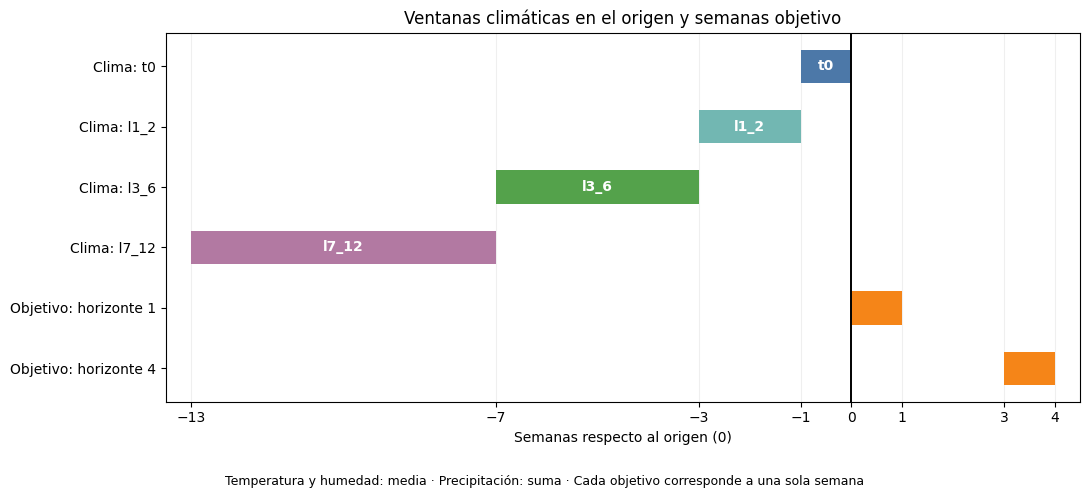

In [46]:
# ventanas anteriores al origen y semanas objetivo.
fig, ax = plt.subplots(figsize=(11, 5))
colores = ["#4C78A8", "#72B7B2", "#54A24B", "#B279A2"]
etiquetas = []

for fila, (ventana, (inicio, fin)) in enumerate(intervalos.items()):
    izquierda = -(fin + 1)
    ancho = fin - inicio + 1
    ax.barh(fila, ancho, left=izquierda, height=0.55,
            color=colores[fila])
    ax.text(izquierda + ancho / 2, fila, ventana,
            ha="center", va="center", color="white", fontweight="bold")
    etiquetas.append(f"Clima: {ventana}")

for fila, horizonte in enumerate(HORIZONTES, start=4):
    ax.barh(fila, 1, left=horizonte - 1, height=0.55,
            color="#F58518")
    etiquetas.append(f"Objetivo: horizonte {horizonte}")

ax.axvline(0, color="black", linewidth=1.4)
ax.set(
    yticks=range(6), yticklabels=etiquetas,
    xticks=[-13, -7, -3, -1, 0, 1, 3, 4],
    xlim=(-13.5, 4.5),
    xlabel="Semanas respecto al origen (0)",
    title="Ventanas climáticas en el origen y semanas objetivo",
)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

fig.text(
    0.5, 0.02,
    "Temperatura y humedad: media · Precipitación: suma · "
    "Cada objetivo corresponde a una sola semana",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(
    FIG_DIR / "fig_10_ventanas_climaticas_y_horizontes.png",
    dpi=300, bbox_inches="tight",
)
plt.show()



La línea vertical en cero representa el origen del pronóstico.

Las barras climáticas resumen semanas que terminan en el origen o antes:

- **t0:** semana que termina en el origen.
- **l1_2:** una y dos semanas antes.
- **l3_6:** de tres a seis semanas antes.
- **l7_12:** de siete a doce semanas antes.

Temperatura y humedad se promedian; la precipitación se acumula.

Las barras naranjas representan las semanas objetivo de los horizontes 1 y 4. Cada objetivo corresponde a una sola semana, no a un acumulado de cuatro semanas.

Estas ventanas son candidatas para estudiar asociaciones con antecedentes climáticos. No demuestran un mecanismo causal ni identifican con precisión un retraso biológico.

Consultar las ventanas en el origen evita utilizar directamente el clima del objetivo. Aun así, debemos comprobar cuándo se publicaron sus datos para garantizar disponibilidad real al pronosticar.

### Importancia

* **Modelado del ciclo biológico del vector:** Las condiciones meteorológicas (como un incremento de lluvias o temperaturas cálidas) no provocan un aumento inmediato en los casos de dengue. Primero favorecen la proliferación de larvas del mosquito *Aedes aegypti*, aceleran su ciclo de maduración e impulsan la incubación del virus. Las ventanas de rezago (*lags*) de varias semanas capturan con precisión este desfase biológico temporal.
* **Prevención de fugas de información (*data leakage*):** Permite diseñar de forma metodológicamente correcta el conjunto de datos para los modelos de aprendizaje automático o series de tiempo, garantizando que el modelo utilice **únicamente información del pasado** para anticipar el futuro, evitando sesgos que invalidarían los pronósticos en la práctica.

### 7.1. Disponibilidad conjunta de casos y clima

Cada fecha candidata genera un pronóstico para cada uno de los 32 estados.

Para cada combinación de estado, origen y objetivo comprobaremos:

1. Que los cuatro antecedentes de casos estén admitidos por el margen correspondiente.
2. Que las doce ventanas climáticas tengan valores finitos en la fecha origen.
3. Que ambas condiciones se cumplan simultáneamente.

La revisión de casos depende de la máscara temporal. La revisión del clima depende de que existan valores para ese estado y origen; no aplicaremos las máscaras de casos al clima.

Conservaremos todas las filas y añadiremos indicadores de cumplimiento. Esto permite distinguir entre una fila que no cumple las condiciones y una fila que fue eliminada.

**Esta es una comprobación retrospectiva:** los indicadores describen admisión y presencia de datos en los archivos actuales. No garantizan disponibilidad real en la fecha del pronóstico.

In [49]:
bloques_disponibilidad = []

for estado in estados:
    bloque = candidatos[
        [
            "ETAPA_OBJETIVO", "MARGEN_DIAS", "HORIZONTE_SEMANAS",
            "FECHA_ORIGEN", "FECHA_OBJETIVO",
            "CUATRO_ANTECEDENTES_ADMITIDOS",
        ]
    ].copy()
    bloque["ESTADO"] = estado

    # Consultar las doce ventanas en el origen, no en el objetivo.
    valores_clima = np.column_stack([
        matriz[estado].reindex(
            pd.DatetimeIndex(bloque["FECHA_ORIGEN"])
        ).to_numpy()
        for matriz in ventanas_clima.values()
    ])

    bloque["N_VENTANAS_CLIMATICAS_VALIDAS"] = (
        np.isfinite(valores_clima).sum(axis=1)
    )
    bloque["CLIMA_COMPLETO"] = (
        bloque["N_VENTANAS_CLIMATICAS_VALIDAS"].eq(len(ventanas_clima))
    )
    bloque["CUMPLE_AMBAS"] = (
        bloque["CUATRO_ANTECEDENTES_ADMITIDOS"]
        & bloque["CLIMA_COMPLETO"]
    )
    bloques_disponibilidad.append(bloque)

disponibilidad = pd.concat(bloques_disponibilidad, ignore_index=True)

claves = ["ETAPA_OBJETIVO", "MARGEN_DIAS", "HORIZONTE_SEMANAS"]
assert len(disponibilidad) == len(candidatos) * len(estados)
assert not disponibilidad.duplicated(
    claves + ["FECHA_OBJETIVO", "ESTADO"]
).any()

resumen_disponibilidad = disponibilidad.groupby(
    claves, sort=False
).agg(
    FECHAS_CANDIDATAS=("FECHA_OBJETIVO", "nunique"),
    FILAS_ESTADO_PRONOSTICO=("ESTADO", "size"),
    CON_ANTECEDENTES_CASOS=("CUATRO_ANTECEDENTES_ADMITIDOS", "sum"),
    CON_DOCE_VENTANAS_CLIMATICAS=("CLIMA_COMPLETO", "sum"),
    CUMPLEN_AMBAS=("CUMPLE_AMBAS", "sum"),
).reset_index()

resumen_disponibilidad["SIN_CLIMA_COMPLETO"] = (
    resumen_disponibilidad["FILAS_ESTADO_PRONOSTICO"]
    - resumen_disponibilidad["CON_DOCE_VENTANAS_CLIMATICAS"]
)

display(resumen_disponibilidad)

print(f"\nFilas conservadas: {len(disponibilidad):,}")
print(
    "Filas con antecedentes admitidos pero clima incompleto:",
    int((
        disponibilidad["CUATRO_ANTECEDENTES_ADMITIDOS"]
        & ~disponibilidad["CLIMA_COMPLETO"]
    ).sum()),
)
print("Comprobación retrospectiva; disponibilidad real pendiente.")

,ETAPA_OBJETIVO,MARGEN_DIAS,HORIZONTE_SEMANAS,FECHAS_CANDIDATAS,FILAS_ESTADO_PRONOSTICO,CON_ANTECEDENTES_CASOS,CON_DOCE_VENTANAS_CLIMATICAS,CUMPLEN_AMBAS,SIN_CLIMA_COMPLETO
0,VALIDACION,0,1,50,1600,1472,1600,1472,0
1,VALIDACION,0,4,50,1600,1472,1600,1472,0
2,PRUEBA,0,1,50,1600,1472,1600,1472,0
3,PRUEBA,0,4,50,1600,1408,1600,1408,0
4,VALIDACION,14,1,48,1536,1408,1536,1408,0
5,VALIDACION,14,4,48,1536,1344,1536,1344,0
6,PRUEBA,14,1,48,1536,1408,1536,1408,0
7,PRUEBA,14,4,48,1536,1312,1536,1312,0
8,VALIDACION,28,1,46,1472,1344,1472,1344,0
9,VALIDACION,28,4,46,1472,1248,1472,1248,0



Filas conservadas: 24,064
Filas con antecedentes admitidos pero clima incompleto: 0
Comprobación retrospectiva; disponibilidad real pendiente.


## 8. Dependencia temporal: Pearson y Spearman

Ahora estudiaremos la asociación entre los casos de una semana y los casos de semanas anteriores, por estado.

Utilizaremos exclusivamente **entrenamiento: 2020–2023**. Compararemos los rezagos de 1, 2, 4, 8, 13, 26 y 52 semanas.

### Dos medidas complementarias

**Pearson sobre `log1p(casos)`** mide la asociación lineal después de transformar los conteos:

$$
Z_t=\log(1+Y_t).
$$

Esta transformación admite ceros y reduce el peso de los conteos muy grandes. El resultado describe la relación en la escala transformada.

**Spearman** mide la asociación entre los rangos de los conteos originales. Describe si semanas con más casos tienden a corresponder con antecedentes que también tienen más casos. Los valores iguales, incluidos los ceros, reciben rangos empatados.

Ambas medidas van de −1 a 1. Una asociación positiva indica que valores altos tienden a acompañarse de valores altos; una negativa indica una tendencia opuesta.

### Comparaciones consistentes

Para cada estado, margen y rezago:

- Ambas semanas deben pertenecer al entrenamiento y estar admitidas.
- Pearson y Spearman utilizarán exactamente los mismos pares.
- Los rezagos se calcularán en el calendario completo, sin comprimir las semanas excluidas.
- Si alguna de las dos series es constante, la correlación quedará ausente.

La figura mostrará el margen de 0 días como referencia descriptiva. También calcularemos cuánto cambian los coeficientes con los márgenes de 14, 28 y 42 días.

**Interpretación:** estas asociaciones ayudan a describir la persistencia temporal. No prueban causalidad, estacionariedad ni utilidad predictiva. Una correlación alta tampoco basta para seleccionar un rezago: esa decisión requiere evaluación de pronósticos.

In [52]:
REZAGOS_CORRELACION = [1, 2, 4, 8, 13, 26, 52]
MEDIDAS = ["PEARSON_LOG1P", "SPEARMAN"]
entrenamiento = calendario_estudio["ETAPA"].eq("ENTRENAMIENTO")
filas_correlaciones = []

for margen in MARGENES:
    admitida = entrenamiento & mascaras[f"MARGEN_{margen}"]

    for rezago in REZAGOS_CORRELACION:
        # Cada fila desplazada conserva su distancia semanal real.
        antecedentes = casos_estudio.shift(rezago)
        pares_validos = (
            admitida & admitida.shift(rezago, fill_value=False)
        )

        for estado in estados:
            actual = casos_estudio.loc[pares_validos, estado]
            anterior = antecedentes.loc[pares_validos, estado]
            calculable = (
                len(actual) >= 2
                and actual.nunique() > 1
                and anterior.nunique() > 1
            )

            pearson = (
                np.log1p(actual).corr(np.log1p(anterior))
                if calculable else np.nan
            )
            spearman = (
                actual.corr(anterior, method="spearman")
                if calculable else np.nan
            )
            filas_correlaciones.append({
                "ESTADO": estado,
                "MARGEN_DIAS": margen,
                "REZAGO_SEMANAS": rezago,
                "PARES_DISPONIBLES": len(actual),
                "PEARSON_LOG1P": pearson,
                "SPEARMAN": spearman,
                "DIFERENCIA_ABSOLUTA": abs(pearson - spearman),
            })

correlaciones = pd.DataFrame(filas_correlaciones)

resumen_pares = correlaciones.groupby(
    ["MARGEN_DIAS", "REZAGO_SEMANAS"]
).agg(
    PARES_MINIMOS=("PARES_DISPONIBLES", "min"),
    PARES_MAXIMOS=("PARES_DISPONIBLES", "max"),
    ESTADOS_CON_PEARSON=("PEARSON_LOG1P", "count"),
    ESTADOS_CON_SPEARMAN=("SPEARMAN", "count"),
).reset_index()

# Comparar cada margen con la referencia de 0 días.
correlaciones_largas = correlaciones.melt(
    id_vars=[
        "ESTADO", "MARGEN_DIAS", "REZAGO_SEMANAS", "PARES_DISPONIBLES"
    ],
    value_vars=MEDIDAS,
    var_name="MEDIDA", value_name="CORRELACION",
)
referencia = correlaciones_largas.loc[
    correlaciones_largas["MARGEN_DIAS"].eq(0),
    ["ESTADO", "REZAGO_SEMANAS", "MEDIDA", "CORRELACION"],
].rename(columns={"CORRELACION": "CORRELACION_MARGEN_0"})

sensibilidad_correlaciones = correlaciones_largas.loc[
    correlaciones_largas["MARGEN_DIAS"].ne(0)
].merge(
    referencia,
    on=["ESTADO", "REZAGO_SEMANAS", "MEDIDA"],
    validate="many_to_one",
)
sensibilidad_correlaciones["CAMBIO"] = (
    sensibilidad_correlaciones["CORRELACION"]
    - sensibilidad_correlaciones["CORRELACION_MARGEN_0"]
)
sensibilidad_correlaciones["CAMBIO_ABSOLUTO"] = (
    sensibilidad_correlaciones["CAMBIO"].abs()
)

resumen_sensibilidad = sensibilidad_correlaciones.groupby(
    ["MEDIDA", "REZAGO_SEMANAS", "MARGEN_DIAS"]
).agg(
    ESTADOS_COMPARABLES=("CAMBIO_ABSOLUTO", "count"),
    MEDIANA_CAMBIO_ABSOLUTO=("CAMBIO_ABSOLUTO", "median"),
    MAXIMO_CAMBIO_ABSOLUTO=("CAMBIO_ABSOLUTO", "max"),
).reset_index()

print("Pares utilizados en entrenamiento:")
display(resumen_pares)

print("\nMediana del cambio absoluto respecto al margen de 0 días:")
display(resumen_sensibilidad.pivot(
    index=["MEDIDA", "REZAGO_SEMANAS"],
    columns="MARGEN_DIAS",
    values="MEDIANA_CAMBIO_ABSOLUTO",
).round(3))

Pares utilizados en entrenamiento:


,MARGEN_DIAS,REZAGO_SEMANAS,PARES_MINIMOS,PARES_MAXIMOS,ESTADOS_CON_PEARSON,ESTADOS_CON_SPEARMAN
0,0,1,196,196,32,32
1,0,2,193,193,32,32
2,0,4,189,189,32,32
3,0,8,185,185,32,32
4,0,13,180,180,32,32
5,0,26,167,167,32,32
6,0,52,147,147,32,32
7,14,1,188,188,32,32
8,14,2,184,184,32,32
9,14,4,177,177,32,32



Mediana del cambio absoluto respecto al margen de 0 días:


MARGEN_DIAS                      14     28     42
MEDIDA        REZAGO_SEMANAS                     
PEARSON_LOG1P 1               0.008  0.010  0.012
              2               0.023  0.028  0.027
              4               0.048  0.052  0.057
              8               0.060  0.078  0.110
              13              0.036  0.047  0.061
              26              0.015  0.025  0.029
              52              0.010  0.020  0.022
SPEARMAN      1               0.017  0.016  0.020
              2               0.026  0.025  0.029
              4               0.042  0.043  0.046
              8               0.051  0.069  0.092
              13              0.024  0.041  0.054
              26              0.019  0.028  0.029
              52              0.011  0.025  0.027

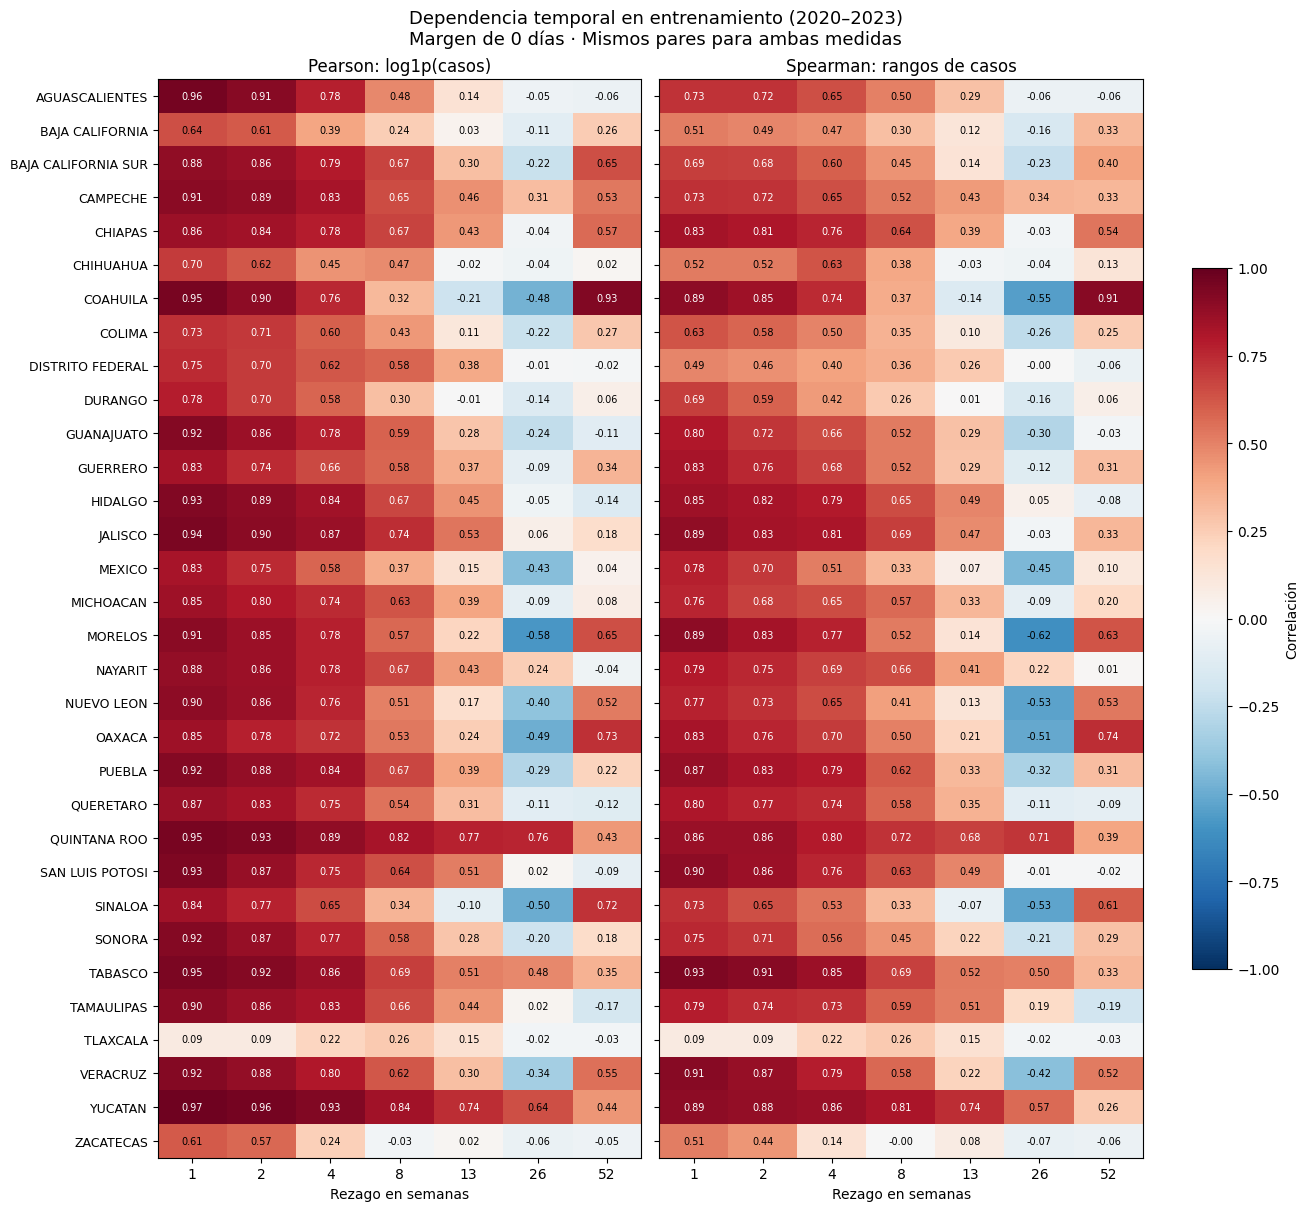

In [51]:
#  las dos medidas con una escala de color común.
referencia_figura = correlaciones.loc[
    correlaciones["MARGEN_DIAS"].eq(0)
]
fig, axes = plt.subplots(
    1, 2, figsize=(13, 12), sharey=True, constrained_layout=True
)
mapa = plt.get_cmap("RdBu_r").copy()
mapa.set_bad("#D9D9D9")

for ax, medida in zip(axes, MEDIDAS):
    tabla = referencia_figura.pivot(
        index="ESTADO", columns="REZAGO_SEMANAS", values=medida
    ).reindex(index=estados, columns=REZAGOS_CORRELACION)

    imagen = ax.imshow(
        np.ma.masked_invalid(tabla.to_numpy()),
        cmap=mapa, vmin=-1, vmax=1, aspect="auto",
    )
    ax.set(
        xticks=range(len(REZAGOS_CORRELACION)),
        xticklabels=REZAGOS_CORRELACION,
        yticks=range(len(estados)), yticklabels=estados,
        xlabel="Rezago en semanas",
        title="Pearson: log1p(casos)" if medida == MEDIDAS[0]
              else "Spearman: rangos de casos",
    )
    ax.tick_params(axis="y", labelsize=9)

    for fila in range(len(estados)):
        for columna in range(len(REZAGOS_CORRELACION)):
            valor = tabla.iloc[fila, columna]
            if np.isfinite(valor):
                ax.text(
                    columna, fila, f"{valor:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="white" if abs(valor) > 0.65 else "black",
                )

fig.colorbar(imagen, ax=axes, shrink=0.65, label="Correlación")
fig.suptitle(
    "Dependencia temporal en entrenamiento (2020–2023)\n"
    "Margen de 0 días · Mismos pares para ambas medidas",
    fontsize=13,
)
fig.savefig(
    FIG_DIR / "fig_11_pearson_spearman_entrenamiento.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


La figura compara asociaciones temporales en entrenamiento, 2020–2023, utilizando el margen de 0 días.

- **Panel izquierdo:** Pearson sobre `log1p(casos)`. Describe asociación lineal en la escala transformada.
- **Panel derecho:** Spearman sobre los rangos de los casos. Describe asociación monotónica y considera los empates.
- **Columnas:** rezagos de 1, 2, 4, 8, 13, 26 y 52 semanas.
- **Colores:** rojo para asociación positiva, azul para negativa y tonos claros para valores cercanos a cero.

Ambas medidas utilizan los mismos pares en cada comparación. La transformación `log1p` reduce el peso de conteos grandes, pero no garantiza varianza constante o estacionariedad.

En muchos estados las asociaciones son mayores en los rezagos cortos. En otros, la frecuencia de ceros y la escasez de registros positivos producen patrones diferentes.

Las diferencias entre Pearson y Spearman muestran que la asociación depende de cómo representamos los valores: magnitudes transformadas o rangos.

Estas correlaciones no demuestran influencia causal ni confirman utilidad predictiva. Los rezagos candidatos deberán evaluarse mediante pronósticos temporales, y su sensibilidad a los márgenes debe revisarse antes de seleccionarlos.

### Importancia

* **Medición de la memoria temporal:** Permite cuantificar con precisión cuántas semanas en el pasado influyen de manera directa sobre el presente en cada estado, identificando el grado de persistencia epidémica.
* **Optimización de características (*feature engineering*):** Sirve como evidencia empírica para definir qué semanas de rezago (*lags*) deben incluirse como variables predictoras en los modelos de pronóstico (por ejemplo, confirmando que los rezagos de 1 a 4 semanas retienen una señal predictiva muy fuerte).
* **Evidencia de la heterogeneidad estatal:** Muestra que mientras los estados con alta transmisión (como Yucatán, Veracruz o Jalisco) conservan fuertes correlaciones temporales a mediano plazo, los estados con transmisión esporádica o nula (como Tlaxcala) muestran correlaciones cercanas a cero en casi todos los rezagos, lo que justifica la necesidad de adaptar los modelos o realizar análisis estratificados por región.

## 9. Resultados del diagnóstico y decisiones pendientes

Este notebook deja comprobados los siguientes puntos:

- Casos, incidencia y clima tienen fechas y estados alineados.
- Los extremos de la serie contienen semanas parcialmente cubiertas.
- Los últimos archivos anuales tienen diferentes fechas internas de actualización. Trabajar con años de etiqueta completos no garantiza datos anuales consolidados.
- Las máscaras conservan el calendario y permiten comparar cuatro márgenes.
- La frecuencia de ceros y la variabilidad difieren entre estados.
- Las agregaciones meteorológicas y las doce ventanas coinciden con sus reconstrucciones.
- Los candidatos conservados tienen clima completo en el origen.
- Pearson y Spearman se calcularon únicamente en entrenamiento, utilizando los mismos pares.

### ¿Qué queda por decidir antes de modelar?

1. **Margen principal:** los márgenes de 0, 14, 28 y 42 días son escenarios de sensibilidad, no estimaciones demostradas del retraso de notificación.
2. **Disponibilidad en el origen:** debemos establecer qué casos y variables climáticas podrían conocerse realmente al emitir el pronóstico.
3. **Predictores finales:** las correlaciones orientan el análisis, pero no bastan para elegir rezagos o ventanas.
4. **Protocolo de ajuste:** debemos definir si el modelo se mantiene fijo o se actualiza, y utilizar únicamente información disponible en cada origen.

Mantendremos entrenamiento en 2020–2023, validación en 2024 y prueba temporal en 2025. Como 2025 ya fue explorado, su evaluación no es completamente ciega.

Guardaremos las tablas, la configuración y las once figuras en los directorios de esta versión compacta. Las decisiones pendientes quedarán registradas como pendientes, sin asignarles valores arbitrarios.

In [54]:
# Comprobar que se conservaron las once figuras antes de exportar.
figuras = sorted(FIG_DIR.glob("fig_*.png"))
numeros_figuras = {
    int(coincidencia.group(1))
    for ruta in figuras
    if (coincidencia := re.match(r"fig_(\d+)_", ruta.name))
}
faltantes = set(range(1, 12)) - numeros_figuras
assert not faltantes, f"Faltan figuras: {sorted(faltantes)}"

RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

tablas_exportar = {
    "auditoria_actualizaciones_anuales": auditoria,
    "calendario_evaluacion_y_mascaras": calendario_estudio.join(mascaras),
    "resumen_periodos_evaluacion": resumen_etapas,
    "resumen_margenes": resumen_margenes,
    "calendario_y_antecedentes_candidatos": candidatos,
    "resumen_candidatos": resumen_candidatos,
    "disponibilidad_casos_clima": disponibilidad,
    "resumen_disponibilidad_casos_clima": resumen_disponibilidad,
    "revision_cobertura_diaria_clima": revision_diaria,
    "comparacion_agregaciones_clima": comparacion_clima,
    "resumen_agregaciones_clima": resumen_clima,
    "diccionario_ventanas_clima": diccionario_ventanas,
    "revision_ventanas_clima": revision_ventanas,
    "resumen_ceros_y_rachas": resumen_ceros,
    "detalle_rachas_ceros": detalle_rachas,
    "magnitud_casos_por_escenario": resumen_magnitud,
    "resumen_incidencia_margen_0": resumen_incidencia,
    "incidencia_media_semanal_por_anio": incidencia_anual,
    "correlaciones_entrenamiento": correlaciones,
    "resumen_pares_correlaciones": resumen_pares,
    "sensibilidad_correlaciones": sensibilidad_correlaciones,
    "resumen_sensibilidad_correlaciones": resumen_sensibilidad,
}

inventario_exportacion = []

for nombre, tabla in tablas_exportar.items():
    salida = (
        tabla.reset_index()
        if tabla.index.name is not None
        or isinstance(tabla.index, pd.MultiIndex)
        else tabla.copy()
    )
    ruta = RESULTADOS_DIR / f"{nombre}.csv"
    salida.to_csv(ruta, index=False, encoding="utf-8-sig")

    inventario_exportacion.append({
        "ARCHIVO": ruta.name,
        "FILAS": len(salida),
        "COLUMNAS": len(salida.columns),
        "TAMANIO_KB": round(ruta.stat().st_size / 1024, 1),
    })

configuracion = {
    "notebook": "05_diagnostico_temporal_compacto",
    "tipo_evaluacion": "retrospectiva",
    "periodo_estudio": {
        "inicio": str(INICIO_ESTUDIO.date()),
        "fin": str(FIN_ESTUDIO.date()),
    },
    "semana": "lunes a domingo; etiqueta en domingo",
    "etapas_por_anio": etapa_por_anio,
    "prueba_completamente_ciega": False,
    "margenes_candidatos_dias": MARGENES,
    "margen_principal_dias": None,
    "regla_disponibilidad_casos": None,
    "regla_disponibilidad_clima": None,
    "protocolo_actualizacion_modelos": None,
    "horizontes_semanas": HORIZONTES,
    "objetivo": "casos de una sola semana",
    "rezagos_casos_candidatos": REZAGOS_CASOS,
    "ventanas_climaticas_candidatas": list(ventanas_clima),
    "predictores_finales": None,
    "agregaciones_semanales_clima": operaciones_clima,
    "correlaciones": {
        "periodo": "entrenamiento 2020–2023",
        "rezagos_semanas": REZAGOS_CORRELACION,
        "medidas": MEDIDAS,
        "mismos_pares_para_ambas": True,
    },
    "modelos_ajustados": False,
    "directorio_figuras": str(FIG_DIR),
    "figuras": [ruta.name for ruta in figuras],
}

ruta_configuracion = RESULTADOS_DIR / "configuracion_diagnostico_05.json"
ruta_configuracion.write_text(
    json.dumps(configuracion, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Directorio de resultados:")
print(RESULTADOS_DIR)
display(pd.DataFrame(inventario_exportacion))

print("\nConfiguración guardada:")
print(ruta_configuracion)
print(f"\nFiguras conservadas: {len(numeros_figuras & set(range(1, 12)))} de 11")
print(FIG_DIR)
print("\nExportación terminada. Decisiones pendientes registradas.")

Directorio de resultados:
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/resultados_05_diagnostico_temporal


,ARCHIVO,FILAS,COLUMNAS,TAMANIO_KB
0,auditoria_actualizaciones_anuales.csv,6,15,0.7
1,calendario_evaluacion_y_mascaras.csv,312,11,23.8
2,resumen_periodos_evaluacion.csv,3,8,0.2
3,resumen_margenes.csv,4,4,0.1
4,calendario_y_antecedentes_candidatos.csv,752,11,46.6
5,resumen_candidatos.csv,16,6,0.5
6,disponibilidad_casos_clima.csv,24064,10,1504.6
7,resumen_disponibilidad_casos_clima.csv,16,9,0.8
8,revision_cobertura_diaria_clima.csv,288,4,7.5
9,comparacion_agregaciones_clima.csv,288,6,13.9



Configuración guardada:
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/resultados_05_diagnostico_temporal/configuracion_diagnostico_05.json

Figuras conservadas: 11 de 11
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/figuras_05_diagnostico_temporal

Exportación terminada. Decisiones pendientes registradas.


## Tarea

Responde las siguientes 10 preguntas con tus propias palabras. Apoya tus respuestas en las tablas, figuras o archivos CSV generados por el notebook.

### Cuestionario

1. **Estructura de los datos.** ¿Qué representan las filas y las columnas de las matrices de casos e incidencia? ¿Por qué debemos comprobar que sus fechas y estados estén alineados?

2. **Semanas parcialmente cubiertas.** ¿Por qué se marcaron para revisión las semanas etiquetadas como `2020-01-05` y `2026-05-24`? Explica qué problema habría al compararlas directamente con semanas completamente cubiertas.

3. **Actualización de los archivos.** ¿Qué diferencia existe entre la fecha del nombre del ZIP y la fecha interna de actualización? Utiliza el archivo de 2024 como ejemplo. ¿Por qué disponer de un archivo de diciembre no garantiza tener un año consolidado?

4. **Márgenes temporales.** ¿Qué representan los márgenes de 0, 14, 28 y 42 días? ¿Cómo cambia el número de semanas admitidas al aumentar el margen? Explica por qué ninguno garantiza que los datos estén consolidados.

5. **Conservación del calendario.** ¿Por qué calculamos los rezagos antes de eliminar semanas no admitidas? Construye un ejemplo pequeño donde eliminar una semana haga que dos filas consecutivas dejen de representar semanas consecutivas.

6. **Ceros y variabilidad.** ¿Qué diferencias observaste entre Tlaxcala y Veracruz en la frecuencia de ceros? ¿Qué significa que la varianza semanal supere la media? Explica por qué estos resultados no bastan para decidir qué modelo utilizar.

7. **Casos e incidencia.** ¿Por qué el estado con más casos no necesariamente tiene la mayor incidencia? Explica también por qué la incidencia media semanal por año no debe interpretarse como incidencia acumulada anual.

8. **Evaluación temporal.** ¿Qué años corresponden a entrenamiento, validación y prueba, y para qué sirve cada etapa? ¿Por qué evitamos repartir las semanas al azar? ¿Por qué la evaluación de 2025 no es completamente ciega?

9. **Origen, objetivo y clima.** Si el origen es el domingo `2024-06-02`, ¿cuáles son las fechas objetivo para los horizontes de 1 y 4 semanas? ¿Qué semana describe `t0` en ambos casos? Explica la diferencia entre tener un dato en los archivos actuales y haber podido conocerlo en el origen.

10. **Pearson y Spearman.** ¿Qué mide cada correlación y por qué aplicamos Pearson a `log1p(casos)`? Identifica en la figura 11 un estado y un rezago donde ambas medidas difieran. ¿Qué permite concluir esa diferencia y qué no permite concluir?

### Ejercicio 1. Semanas admitidas según el margen

Utiliza `resumen_margenes.csv`.

- Construye una gráfica de barras con `MARGEN_DIAS` en el eje horizontal y `SEMANAS_ADMITIDAS` en el vertical.
- Coloca el número de semanas encima de cada barra.
- Añade título y nombres de los ejes.
- Calcula cuántas semanas admitidas se pierden al pasar de 0 a 42 días de margen.
- Escribe una interpretación de tres a cinco líneas sobre el efecto del margen y su limitación.

Guarda la figura como `tarea_01_semanas_por_margen.png`.

### Ejercicio 2. Dependencia temporal en dos estados

Utiliza `correlaciones_entrenamiento.csv`.

- Selecciona únicamente el margen de 0 días y los estados **Veracruz** y **Tlaxcala**.
- Construye una figura con dos paneles, uno por estado.
- En cada panel, grafica `PEARSON_LOG1P` y `SPEARMAN` frente a `REZAGO_SEMANAS`, utilizando líneas con marcadores.
- Ordena los rezagos de menor a mayor. Usa la misma escala vertical, de −1 a 1, en ambos paneles.
- Añade una línea horizontal en cero, títulos, nombres de los ejes y leyenda.
- Escribe una interpretación de cinco a ocho líneas: compara los estados, las dos medidas y el comportamiento de los rezagos cortos y largos.

Guarda la figura como `tarea_02_correlaciones_por_rezago.png`.
